In [2]:
print("hello")

hello


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

In [4]:
# Loading data
clients = pd.read_parquet('D:\Evocabank task\clients.parquet')
loans = pd.read_parquet('D:\Evocabank task\loans.parquet')
deposits = pd.read_parquet('D:\Evocabank task\deposits.parquet')
transactions = pd.read_parquet('D:\Evocabank task\card_transactions.parquet')

# Quick shape check
print(f"Clients shape: {clients.shape}")
print(f"Loans shape: {loans.shape}")
print(f"Deposits shape: {deposits.shape}")
print(f"Transactions shape: {transactions.shape}")

Clients shape: (5010, 8)
Loans shape: (3616, 10)
Deposits shape: (4116, 10)
Transactions shape: (364854, 8)


In [5]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   client_id           5010 non-null   str    
 1   age                 5010 non-null   int64  
 2   gender              4916 non-null   str    
 3   region              5010 non-null   str    
 4   employment_status   5010 non-null   str    
 5   education_level     4822 non-null   str    
 6   monthly_salary_amd  4721 non-null   float64
 7   registration_date   5010 non-null   object 
dtypes: float64(1), int64(1), object(1), str(5)
memory usage: 482.0+ KB


In [6]:
clients.describe()

,age,monthly_salary_amd
count,5010.000000,4.721000e+03
mean,38.980838,3.470586e+05
std,11.315510,2.081115e+05
min,18.000000,4.078300e+04
25%,30.000000,1.769120e+05
50%,38.000000,3.014090e+05
75%,47.000000,4.796050e+05
max,73.000000,1.276823e+06


In [7]:
clients.head()

,client_id,age,gender,region,employment_status,education_level,monthly_salary_amd,registration_date
0,C01053,40,Male,Armavir,Employed,Bachelor,593595.0,2025-12-19
1,C02991,65,Female,Aragatsotn,Student,Secondary,132486.0,2021-07-17
2,C01789,28,Male,Yerevan,Employed,Bachelor,201714.0,2025-03-10
3,C00765,30,Female,Yerevan,Student,Master,242505.0,2020-06-16
4,C03248,47,Male,Yerevan,Employed,Vocational,90113.0,2020-07-06


In [8]:
clients.isnull().sum()

client_id               0
age                     0
gender                 94
region                  0
employment_status       0
education_level       188
monthly_salary_amd    289
registration_date       0
dtype: int64

<Axes: >

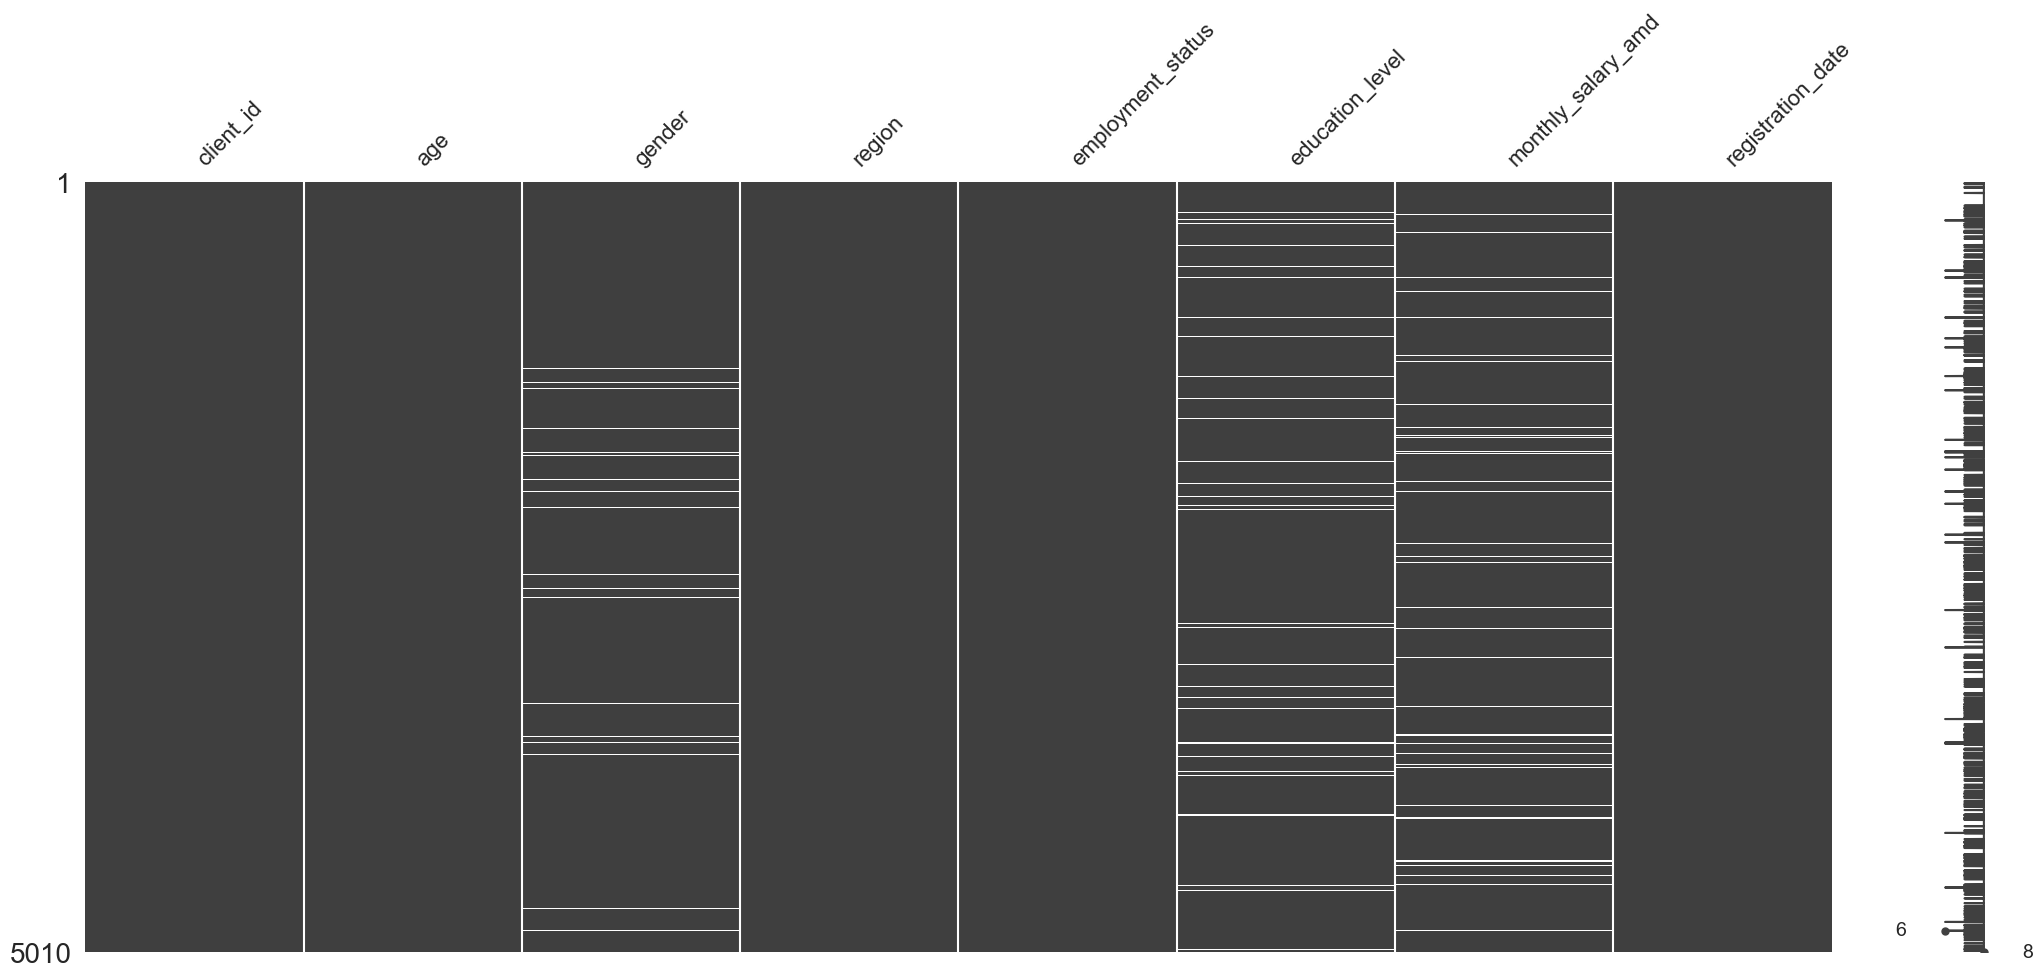

In [9]:
missingno.matrix(clients)

<Axes: >

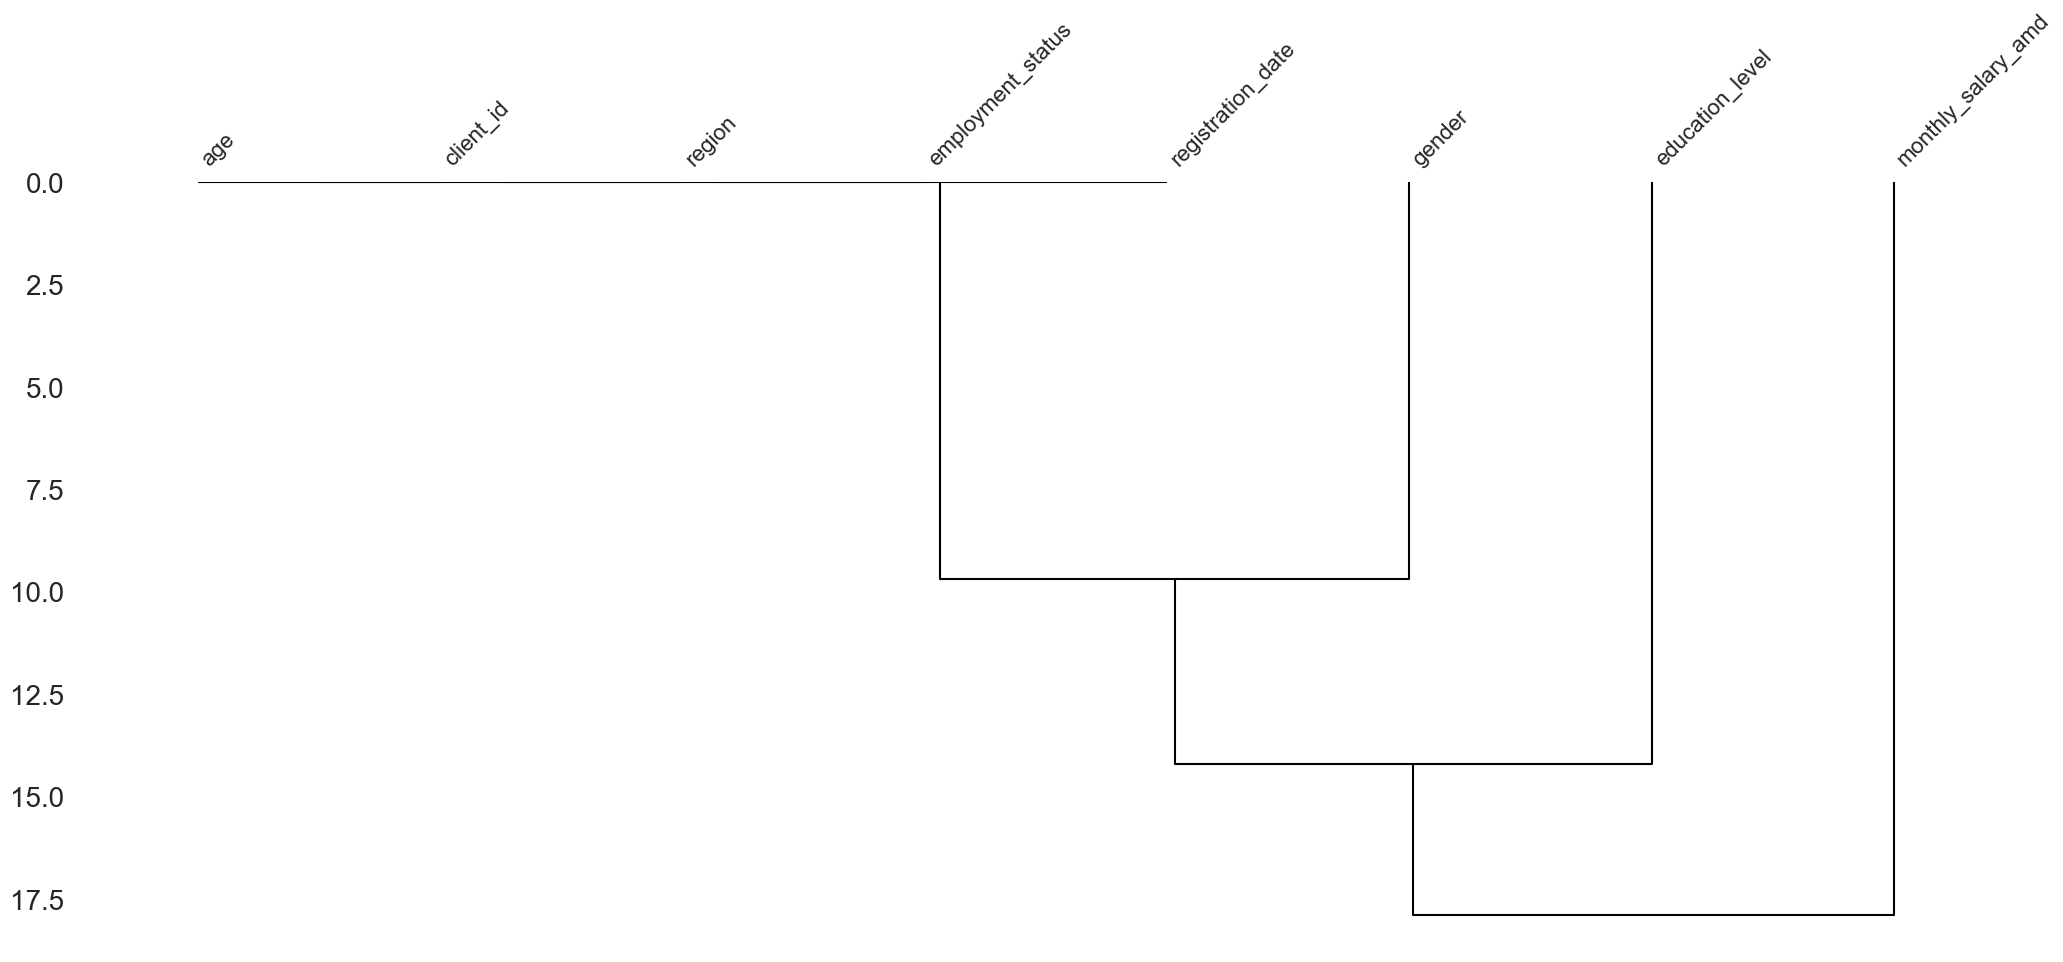

In [10]:
missingno.dendrogram(clients)

In [11]:
# count duplicates
clients.duplicated().sum()

np.int64(10)

In [12]:
clients[clients.duplicated(keep=False)]

,client_id,age,gender,region,employment_status,education_level,monthly_salary_amd,registration_date
32,C00706,23,Male,Yerevan,Employed,Vocational,265403.0,2022-06-29
52,C00107,45,Female,Yerevan,Retired,Secondary,103442.0,2024-12-31
157,C00590,70,Male,Yerevan,Employed,Master,457519.0,2023-01-14
420,C00590,70,Male,Yerevan,Employed,Master,457519.0,2023-01-14
428,C02469,44,Female,Aragatsotn,Self-employed,Master,379113.0,2023-10-23
475,C01056,29,Male,Yerevan,Retired,Bachelor,481844.0,2025-03-01
635,C01601,42,Male,Lori,Retired,Master,631058.0,2020-01-22
734,C00107,45,Female,Yerevan,Retired,Secondary,103442.0,2024-12-31
1151,C01502,31,Male,Yerevan,Unemployed,Bachelor,326368.0,2020-08-01
1165,C01601,42,Male,Lori,Retired,Master,631058.0,2020-01-22


In [13]:
# duplicate removal
initial_rows = len(clients)
clients = clients.drop_duplicates()
print(f"Dropped {initial_rows - len(clients)} duplicates")

Dropped 10 duplicates


In [14]:
clients.dtypes

client_id                 str
age                     int64
gender                    str
region                    str
employment_status         str
education_level           str
monthly_salary_amd    float64
registration_date      object
dtype: object

In [ ]:
# missing values in monthly_salary_amd with median because it is more stable to outliers than mean
# missing values in employment_status with most frequent status
if 'monthly_salary_amd' in clients.columns:
    clients['monthly_salary_amd'] = clients['monthly_salary_amd'].fillna(clients['monthly_salary_amd'].median())
clients['education_level'] = clients['education_level'].fillna('Unknown')
clients['gender'] = clients['gender'].fillna('Unknown')

   

In [16]:
clients['registration_date'] = pd.to_datetime(clients['registration_date']) # Missing Date Conversion

In [17]:
clients.dtypes

client_id                       str
age                           int64
gender                          str
region                          str
employment_status               str
education_level                 str
monthly_salary_amd          float64
registration_date     datetime64[s]
dtype: object

In [18]:
deposits.head()

,deposit_id,client_id,deposit_type,balance,balance_amd,currency,interest_rate_pct,open_date,maturity_date,deposit_status
0,D002997,C00964,Savings Account,10747,4513740,EUR,5.90,2021-09-15,None,Active
1,D000747,C04922,Savings Account,10971904,10971904,AMD,2.88,2024-02-14,None,Active
2,D003041,C00016,Term Deposit,3366766,3366766,AMD,9.64,2020-09-24,2022-09-23,Closed
3,D003121,C02914,Demand Deposit,254709,254709,AMD,0.00,2024-12-08,None,Active
4,D002762,C04467,Savings Account,13359,5343600,USD,4.13,2021-02-22,None,Active


In [19]:
deposits.info()

<class 'pandas.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   deposit_id         4116 non-null   str    
 1   client_id          4116 non-null   str    
 2   deposit_type       4116 non-null   str    
 3   balance            4116 non-null   int64  
 4   balance_amd        4116 non-null   int64  
 5   currency           4116 non-null   str    
 6   interest_rate_pct  3952 non-null   float64
 7   open_date          4116 non-null   object 
 8   maturity_date      1464 non-null   object 
 9   deposit_status     4116 non-null   str    
dtypes: float64(1), int64(2), object(2), str(5)
memory usage: 464.8+ KB


In [20]:
deposits.isnull().sum()

deposit_id              0
client_id               0
deposit_type            0
balance                 0
balance_amd             0
currency                0
interest_rate_pct     164
open_date               0
maturity_date        2652
deposit_status          0
dtype: int64

In [21]:
deposits.describe()

,balance,balance_amd,interest_rate_pct
count,4.116000e+03,4.116000e+03,3952.000000
mean,1.643236e+06,3.372255e+06,3.935832
std,3.086102e+06,3.980747e+06,3.566965
min,5.500000e+01,1.230700e+04,0.000000
25%,1.471125e+04,4.495260e+05,0.000000
50%,2.680845e+05,1.541860e+06,3.670000
75%,1.637050e+06,5.037010e+06,5.832500
max,2.160750e+07,2.160750e+07,12.490000


<Axes: >

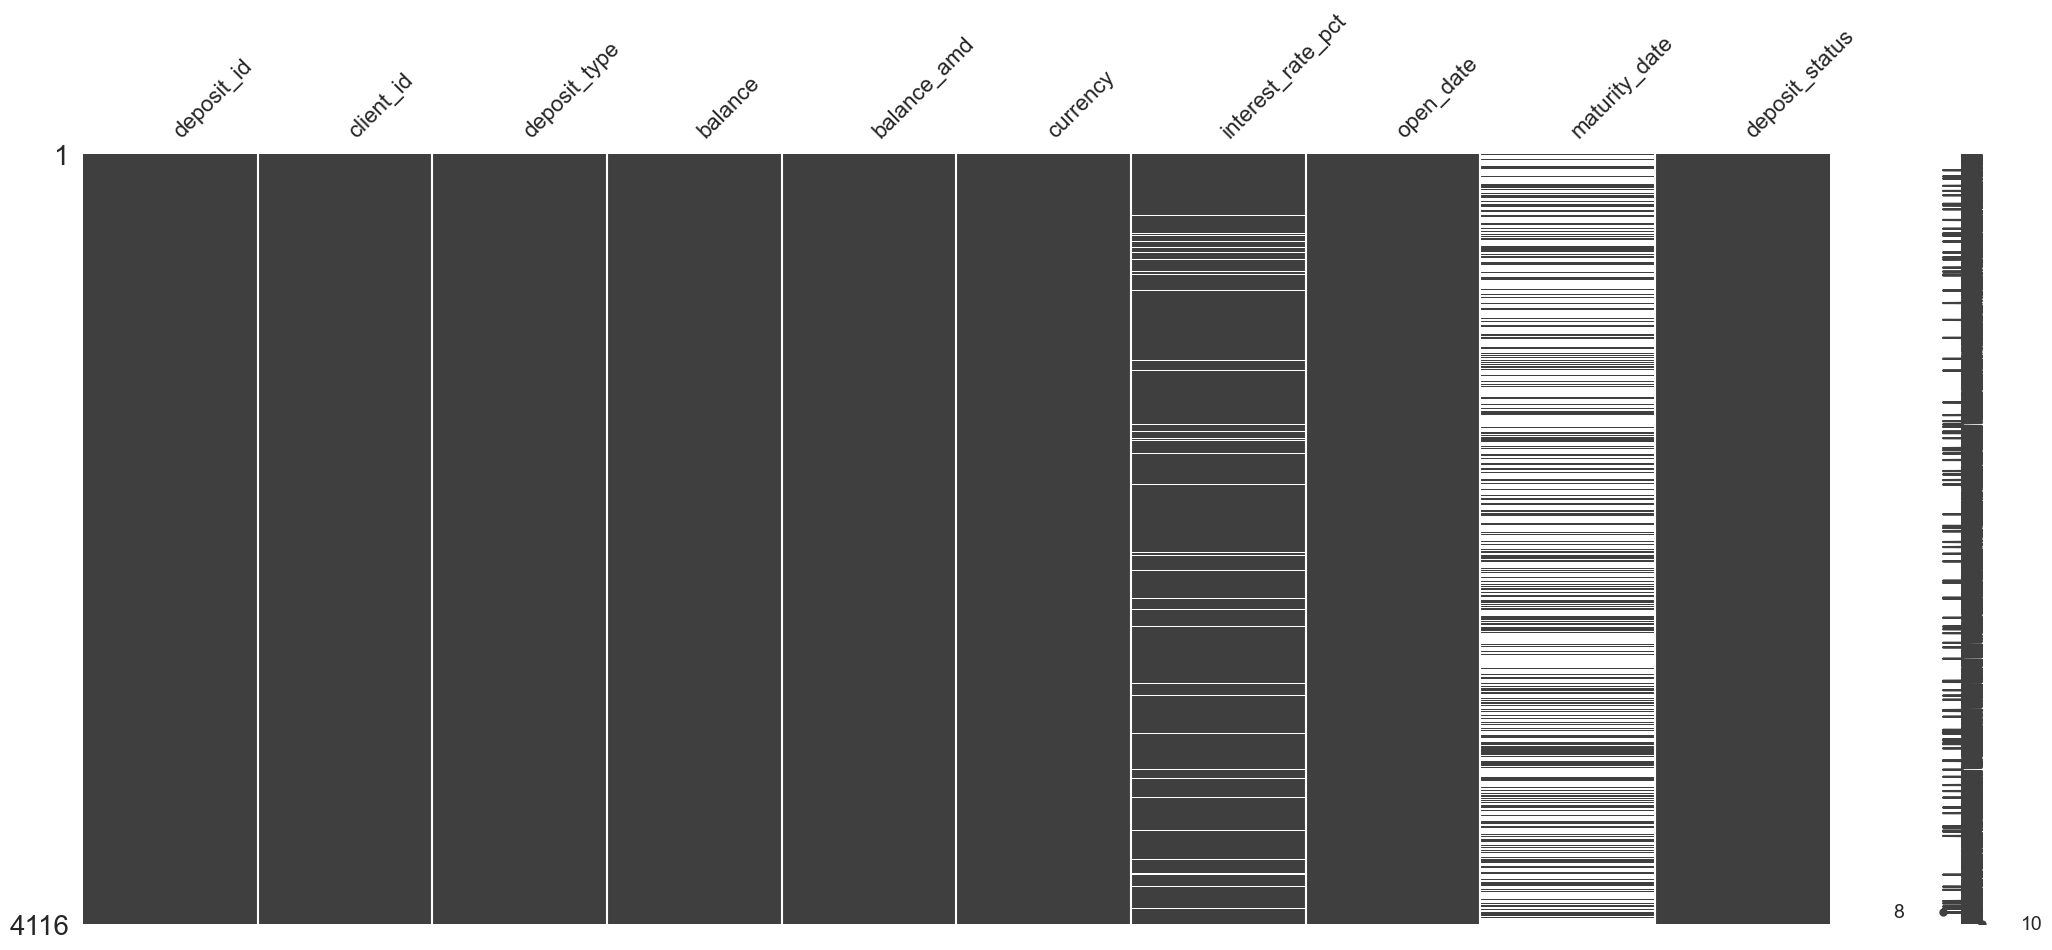

In [22]:
missingno.matrix(deposits)

In [23]:
deposits['interest_rate_pct'] = deposits['interest_rate_pct'].fillna(0) # Handled missing interest rate
deposits['open_date'] = pd.to_datetime(deposits['open_date'])           # Missing Date Conversion
deposits['maturity_date'] = pd.to_datetime(deposits['maturity_date'])   # Missing Date Conversion

In [24]:
loans.head()

,loan_id,client_id,loan_type,loan_amount_amd,interest_rate_pct,start_date,end_date,duration_months,monthly_payment_amd,loan_status
0,L002918,C02002,Consumer,9698220,19.16,2022-01-12,2025-04-11,39,18666.0,Closed
1,L001256,C00059,Mortgage,445541824,11.03,2025-04-13,2038-02-05,154,387122.0,Active
2,L002801,C04490,Credit Line,6047370,15.84,2024-08-08,2025-02-06,6,105496.0,Closed
3,L002145,C04040,Credit Line,10624796,19.41,2020-11-15,2022-05-16,18,48934.0,Closed
4,L001937,C02843,Consumer,14511348,13.27,2023-06-25,2023-12-24,6,209418.0,Closed


In [25]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_id              3616 non-null   str    
 1   client_id            3616 non-null   str    
 2   loan_type            3616 non-null   str    
 3   loan_amount_amd      3616 non-null   int64  
 4   interest_rate_pct    3509 non-null   float64
 5   start_date           3616 non-null   object 
 6   end_date             3616 non-null   object 
 7   duration_months      3616 non-null   int64  
 8   monthly_payment_amd  3501 non-null   float64
 9   loan_status          3616 non-null   str    
dtypes: float64(2), int64(2), object(2), str(4)
memory usage: 376.7+ KB


In [26]:
loans.isnull().sum()

loan_id                  0
client_id                0
loan_type                0
loan_amount_amd          0
interest_rate_pct      107
start_date               0
end_date                 0
duration_months          0
monthly_payment_amd    115
loan_status              0
dtype: int64

<Axes: >

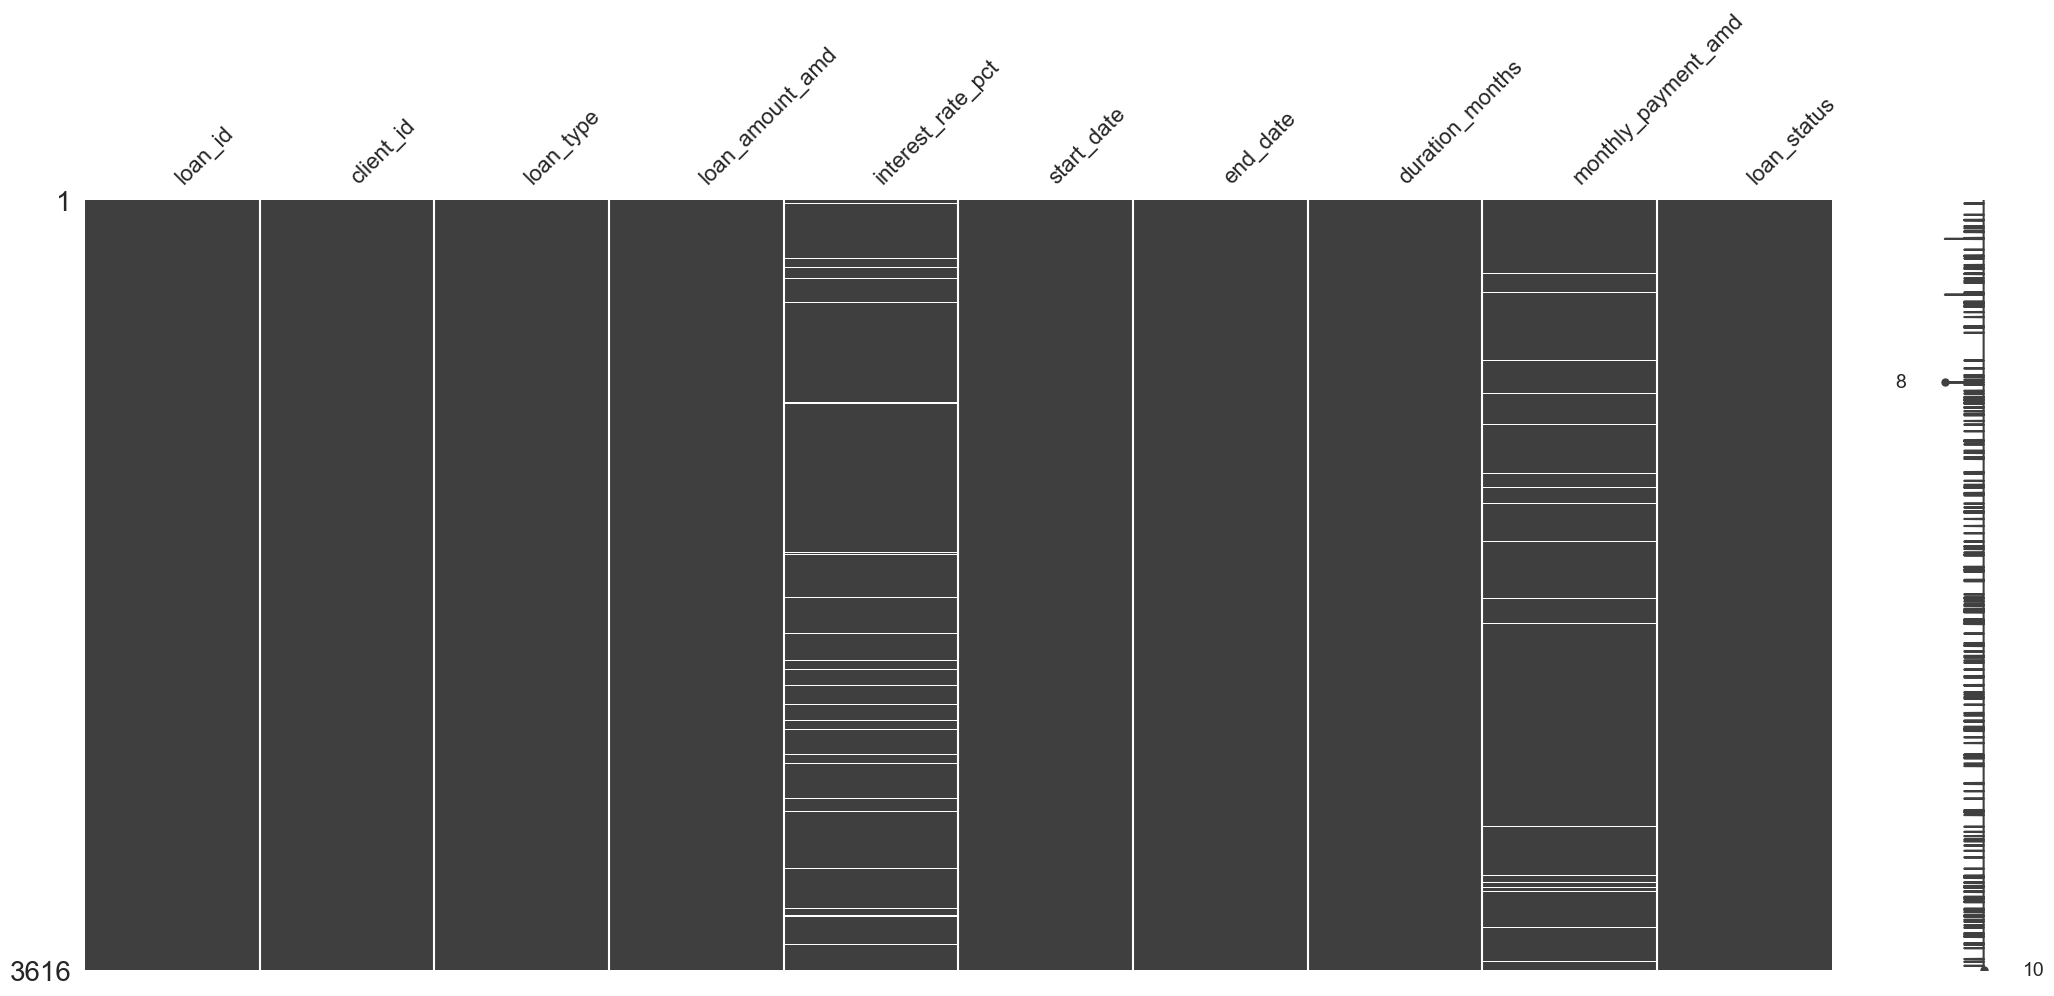

In [27]:
missingno.matrix(loans)

In [ ]:
if loans['interest_rate_pct'].isnull().any():
    loans['interest_rate_pct'] = loans['interest_rate_pct'].fillna(loans['interest_rate_pct'].median())

In [29]:
loans['monthly_payment_amd'] = loans['monthly_payment_amd'].fillna(loans['monthly_payment_amd'].median()) # Handled missing payment
loans['start_date'] = pd.to_datetime(loans['start_date']) # Missing Date Conversion
loans['end_date'] = pd.to_datetime(loans['end_date'])     # Missing Date Conversion

In [30]:
transactions.head()

,transaction_id,client_id,transaction_date,amount_amd,currency,merchant_category,transaction_type,city
0,T0335712,C02897,2020-01-01,43088,EUR,Clothing & Accessories,Purchase,Yerevan
1,T0326960,C03638,2020-01-01,28084,USD,Healthcare,Purchase,Gavar
2,T0194541,C01576,2020-01-01,26693,USD,Clothing & Accessories,Online Payment,Abovyan
3,T0205037,C01822,2020-01-01,29593,AMD,ATM Withdrawal,Purchase,Yerevan
4,T0316486,C00233,2020-01-01,33365,AMD,Healthcare,Refund,Yerevan


In [31]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 364854 entries, 0 to 364853
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   transaction_id     364854 non-null  str   
 1   client_id          364854 non-null  str   
 2   transaction_date   364854 non-null  object
 3   amount_amd         364854 non-null  int64 
 4   currency           364854 non-null  str   
 5   merchant_category  354117 non-null  str   
 6   transaction_type   364854 non-null  str   
 7   city               346523 non-null  str   
dtypes: int64(1), object(1), str(6)
memory usage: 38.5+ MB


In [32]:
transactions.describe()

,amount_amd
count,3.648540e+05
mean,3.525272e+04
std,4.372375e+04
min,5.000000e+02
25%,1.695000e+04
50%,2.968900e+04
75%,4.652800e+04
max,2.795339e+06


In [33]:
transactions.isnull().sum()

transaction_id           0
client_id                0
transaction_date         0
amount_amd               0
currency                 0
merchant_category    10737
transaction_type         0
city                 18331
dtype: int64

<Axes: >

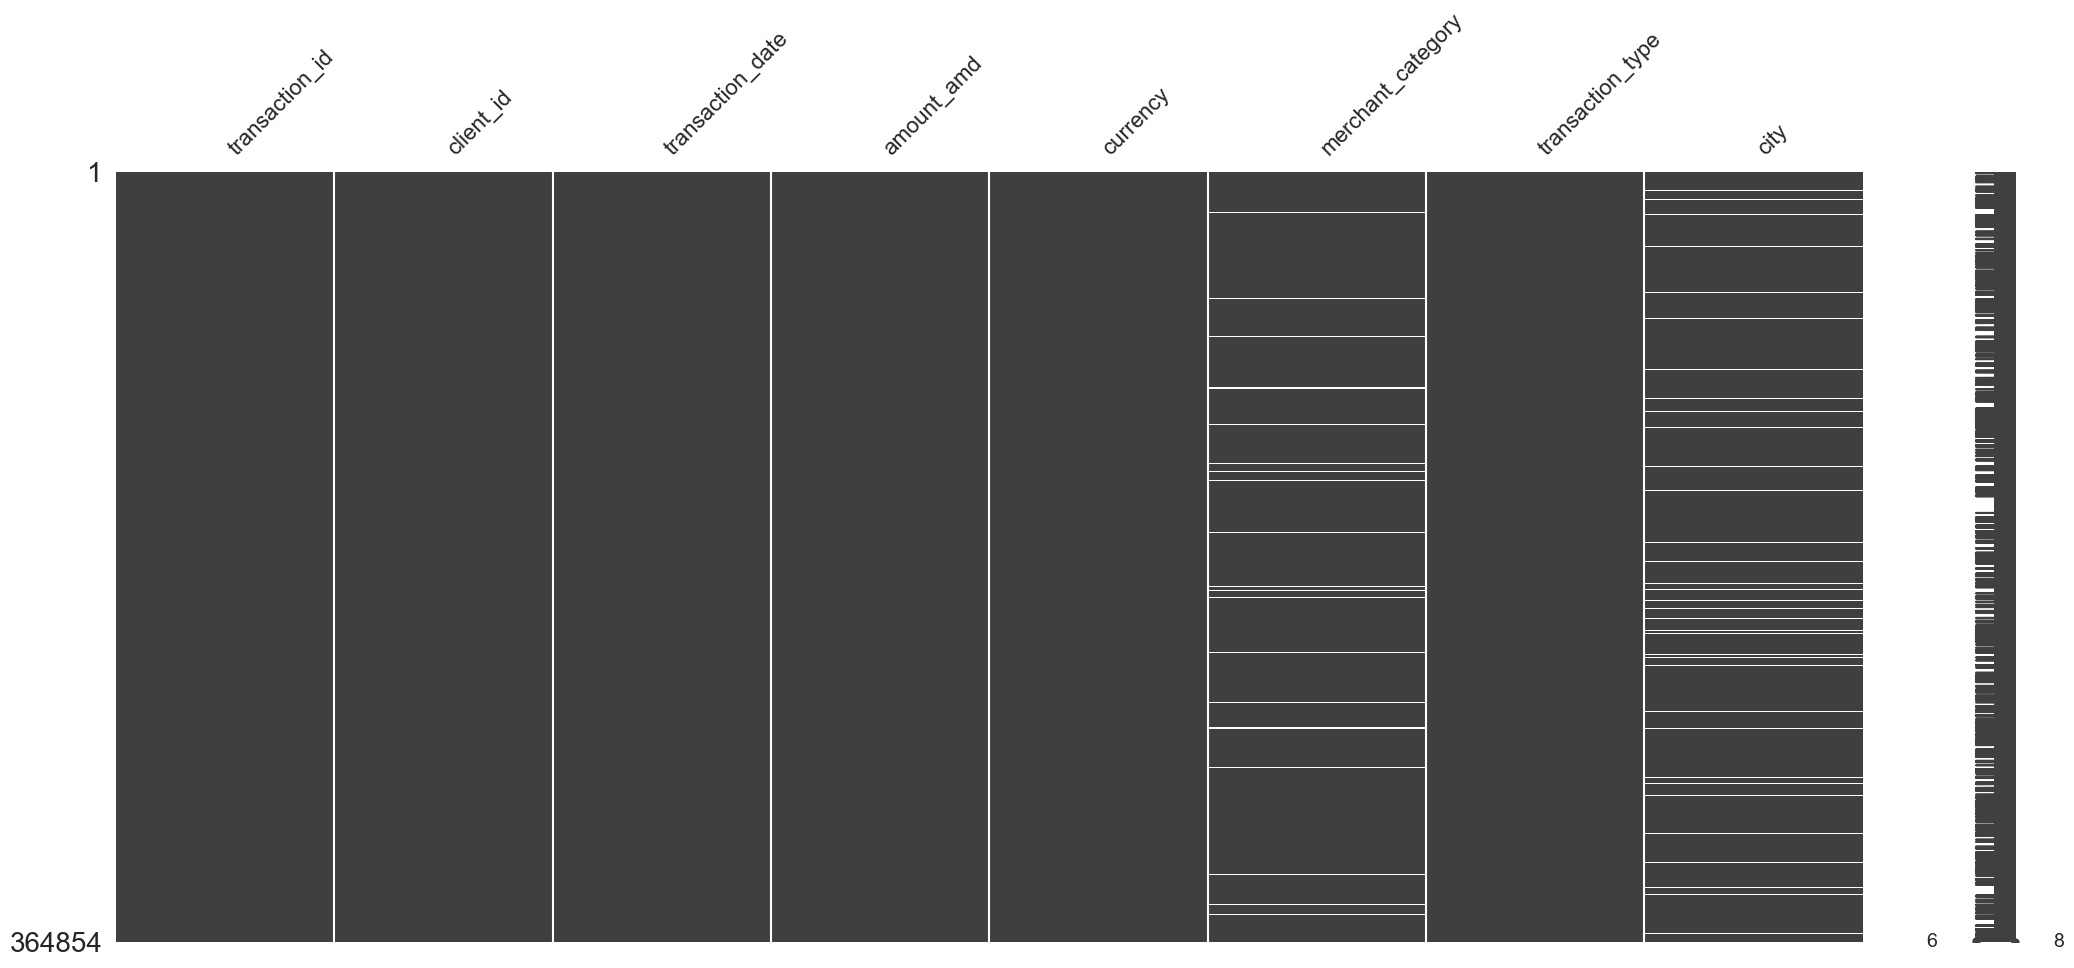

In [34]:
missingno.matrix(transactions)

In [ ]:
transactions['merchant_category'] = transactions['merchant_category'].fillna('Unknown')
transactions['city'] = transactions['city'].fillna('Unknown')
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date']) # Missing Date Conversion
transactions.isnull().sum()

transaction_id       0
client_id            0
transaction_date     0
amount_amd           0
currency             0
merchant_category    0
transaction_type     0
city                 0
dtype: int64

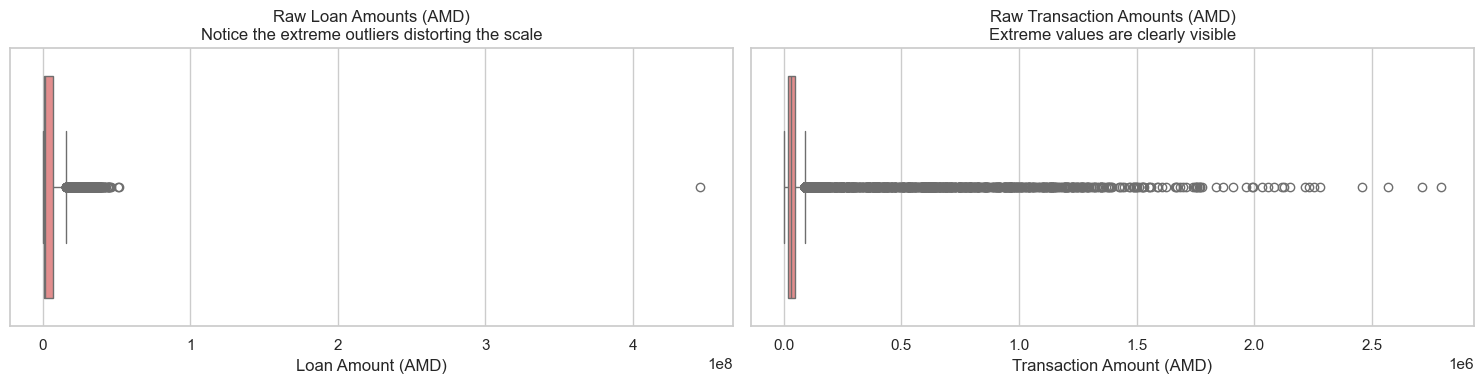

In [36]:
# ==========================================
# Task 4.2: EDA - Visualizing Raw Outliers
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Raw Loan Amounts Boxplot
sns.boxplot(x=loans['loan_amount_amd'], ax=axes[0], color='lightcoral')
axes[0].set_title("Raw Loan Amounts (AMD)\nNotice the extreme outliers distorting the scale")
axes[0].set_xlabel("Loan Amount (AMD)")

# Raw Transaction Amounts Boxplot
sns.boxplot(x=transactions['amount_amd'], ax=axes[1], color='lightcoral')
axes[1].set_title("Raw Transaction Amounts (AMD)\nExtreme values are clearly visible")
axes[1].set_xlabel("Transaction Amount (AMD)")

plt.tight_layout()
plt.show()

# After running this, look at the plots. You will likely see the main "box" squashed 
# to the far left, with a few dots (outliers) pushed millions or billions of AMD to the right.

Loans capped at: 37,684,992 AMD
Transactions capped at: 641,237 AMD


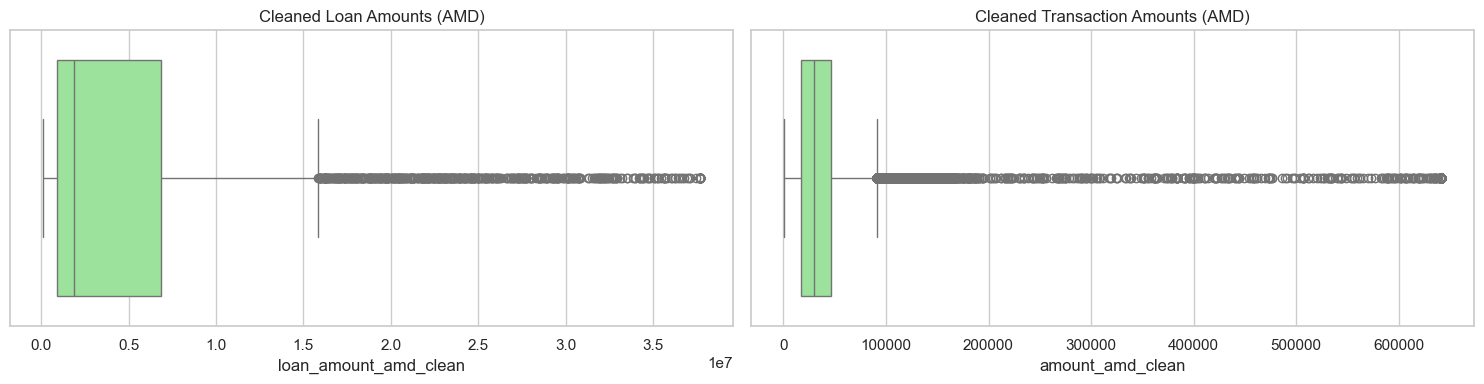

In [37]:
# ==========================================
# Task 4.1 (Continued): Handling Outliers
# ==========================================

# 1. Cap Loan Outliers
# We use the 99th percentile. Anything above is likely a data entry error.
loan_upper_limit = loans['loan_amount_amd'].quantile(0.99)
loans['loan_amount_amd_clean'] = np.where(
    loans['loan_amount_amd'] > loan_upper_limit, 
    loan_upper_limit, 
    loans['loan_amount_amd']
)

# 2. Cap Transaction Outliers
# We use the 99.9th percentile for transactions (to allow for rare valid large purchases)
tx_upper_limit = transactions['amount_amd'].quantile(0.999)
transactions['amount_amd_clean'] = np.where(
    transactions['amount_amd'] > tx_upper_limit,
    tx_upper_limit,
    transactions['amount_amd']
)

print(f"Loans capped at: {loan_upper_limit:,.0f} AMD")
print(f"Transactions capped at: {tx_upper_limit:,.0f} AMD")

# Let's quickly see the "After" picture!
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x=loans['loan_amount_amd_clean'], ax=axes[0], color='lightgreen')
axes[0].set_title("Cleaned Loan Amounts (AMD)")
sns.boxplot(x=transactions['amount_amd_clean'], ax=axes[1], color='lightgreen')
axes[1].set_title("Cleaned Transaction Amounts (AMD)")
plt.tight_layout()
plt.show()

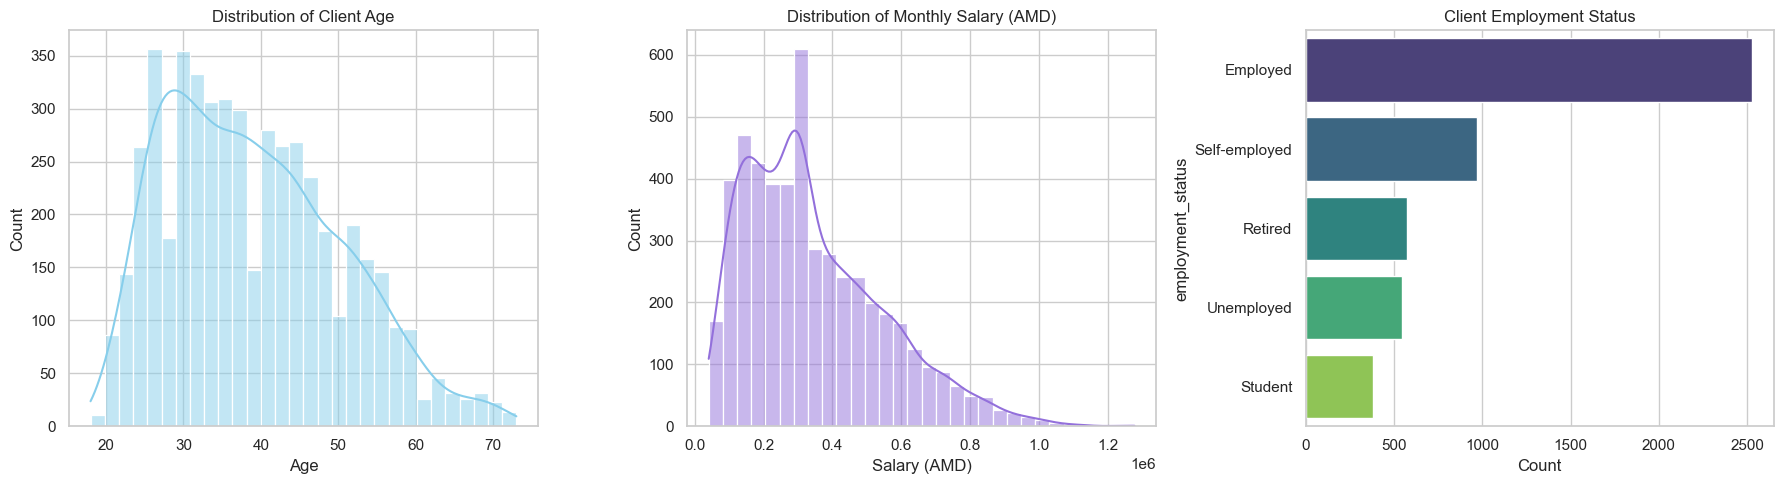

In [38]:
# ==========================================
# Task 4.2: Standard EDA - Demographics
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Age Distribution
sns.histplot(clients['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Client Age')
axes[0].set_xlabel('Age')

# Cleaned Salary Distribution
sns.histplot(clients['monthly_salary_amd'], bins=30, kde=True, ax=axes[1], color='mediumpurple')
axes[1].set_title('Distribution of Monthly Salary (AMD)')
axes[1].set_xlabel('Salary (AMD)')

# Employment Status
sns.countplot(y=clients['employment_status'], order=clients['employment_status'].value_counts().index, ax=axes[2], palette='viridis')
axes[2].set_title('Client Employment Status')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

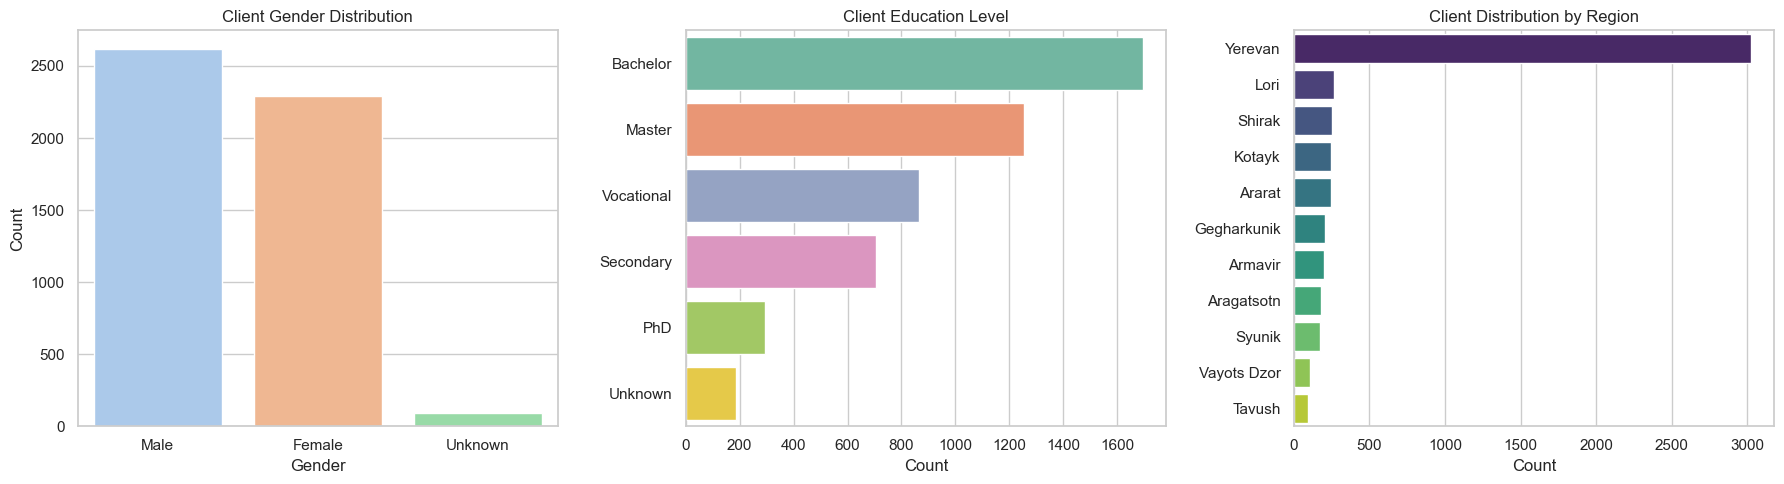

In [39]:
# ==========================================
# Task 4.2: EDA - Client Categoricals
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender Distribution
sns.countplot(data=clients, x='gender', palette='pastel', ax=axes[0])
axes[0].set_title('Client Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Education Level
sns.countplot(data=clients, y='education_level', order=clients['education_level'].value_counts().index, palette='Set2', ax=axes[1])
axes[1].set_title('Client Education Level')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

# Region (Armenia Context)
sns.countplot(data=clients, y='region', order=clients['region'].value_counts().index, palette='viridis', ax=axes[2])
axes[2].set_title('Client Distribution by Region')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Business Insight: Look to see if the bank is heavily concentrated in Yerevan, 
# and what the predominant education level of the customer base is.

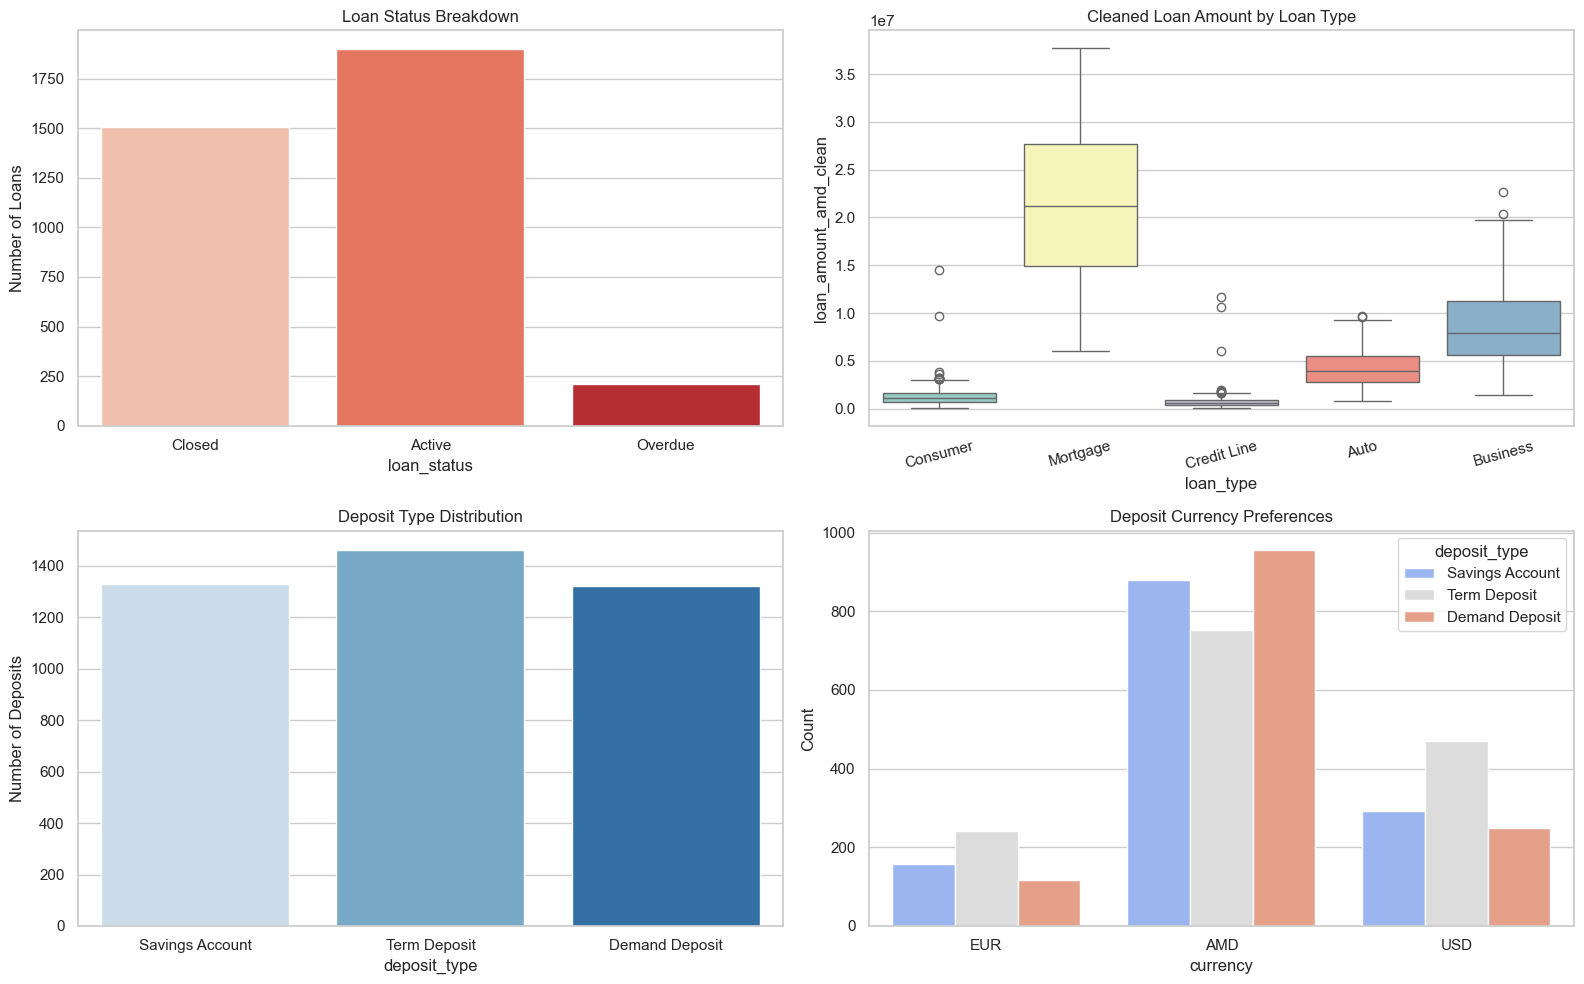

In [40]:
# ==========================================
# Task 4.2: EDA - Loans & Deposits Breakdown
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Loan Status (Active vs Overdue vs Closed)
sns.countplot(data=loans, x='loan_status', palette='Reds', ax=axes[0, 0])
axes[0, 0].set_title('Loan Status Breakdown')
axes[0, 0].set_ylabel('Number of Loans')

# 2. Cleaned Loan Amount by Type
sns.boxplot(data=loans, x='loan_type', y='loan_amount_amd_clean', palette='Set3', ax=axes[0, 1])
axes[0, 1].set_title('Cleaned Loan Amount by Loan Type')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Deposit Type Breakdown
sns.countplot(data=deposits, x='deposit_type', palette='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Deposit Type Distribution')
axes[1, 0].set_ylabel('Number of Deposits')

# 4. Deposit Currency Preference
sns.countplot(data=deposits, x='currency', hue='deposit_type', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Deposit Currency Preferences')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Business Insight: 
# - Look at the Loan Status: High 'Overdue' counts indicate credit risk.
# - Look at Deposit Currencies: Are Term Deposits mostly in USD or AMD?

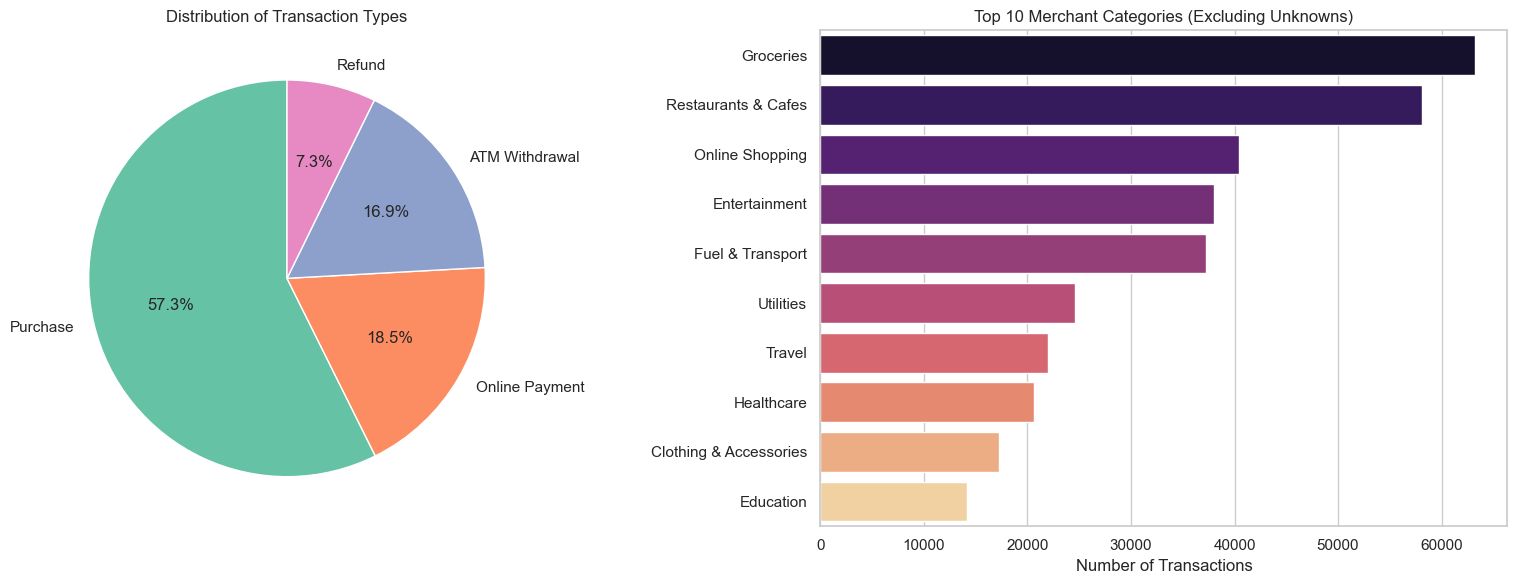

In [41]:
# ==========================================
# Task 4.2: EDA - Transaction Behaviors
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Transaction Types Pie Chart
tx_types = transactions['transaction_type'].value_counts()
axes[0].pie(tx_types.values, labels=tx_types.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("Set2"))
axes[0].set_title('Distribution of Transaction Types')

# 2. Top 10 Merchant Categories by Volume
# We exclude 'Unknown' to see the actual valid merchants
valid_merchants = transactions[transactions['merchant_category'] != 'Unknown']
top_merchants = valid_merchants['merchant_category'].value_counts().head(10)

sns.barplot(x=top_merchants.values, y=top_merchants.index, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Merchant Categories (Excluding Unknowns)')
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Business Insight: 
# Are clients primarily using cards for ATMs (cash withdrawals), or actual Purchases / Online Payments? 
# This tells you if they treat the bank as just a place to get cash, or for daily digital usage.

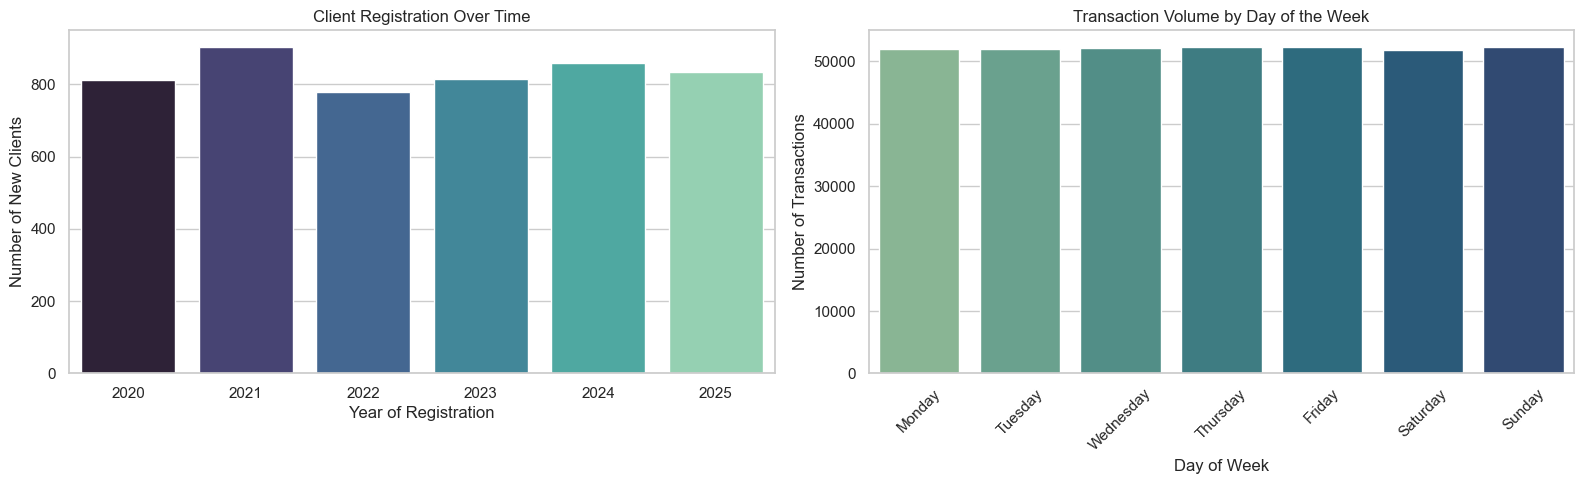

In [42]:
# ==========================================
# Task 4.2: EDA - Time & Temporal Patterns
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Client Acquisition Over Time
clients['registration_year'] = clients['registration_date'].dt.year
sns.countplot(data=clients, x='registration_year', palette='mako', ax=axes[0])
axes[0].set_title('Client Registration Over Time')
axes[0].set_xlabel('Year of Registration')
axes[0].set_ylabel('Number of New Clients')

# 2. Transactions by Day of Week
# Extract day of week (Monday=0, Sunday=6)
transactions['day_of_week'] = transactions['transaction_date'].dt.day_name()
days_order =['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(data=transactions, x='day_of_week', order=days_order, palette='crest', ax=axes[1])
axes[1].set_title('Transaction Volume by Day of the Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Business Insight: 
# - Registration: Is the bank growing recently, or is the user base mostly older cohorts?
# - Transactions: Do clients spend more on weekends or weekdays?

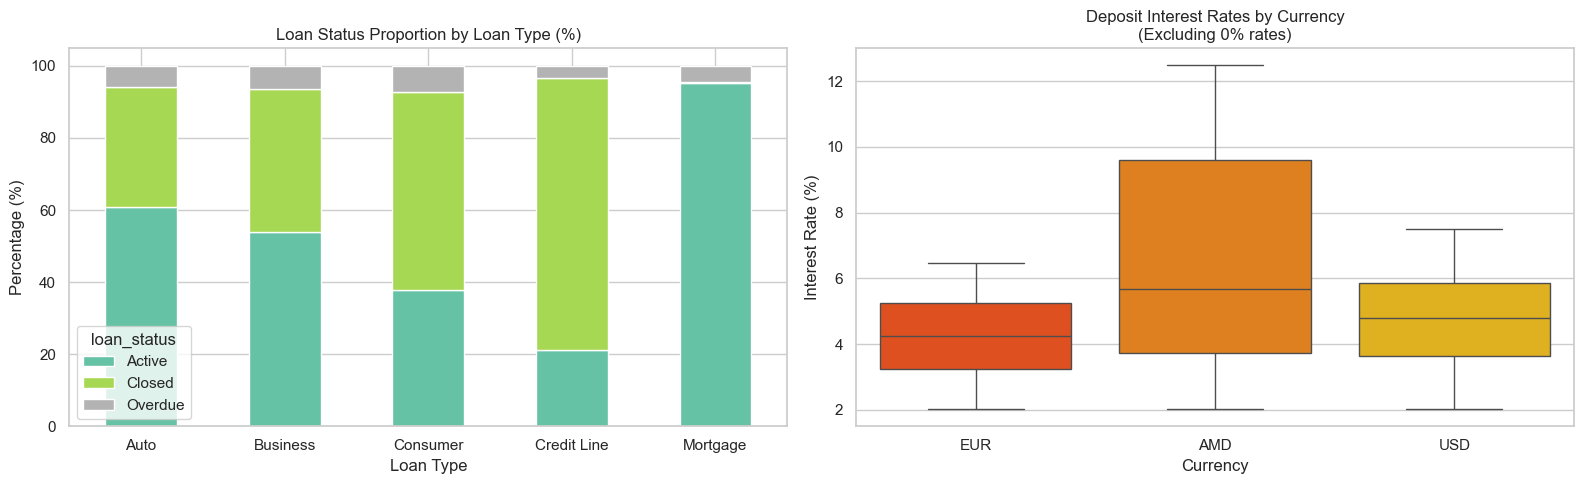

In [43]:
# ==========================================
# Task 4.2: EDA - Credit Risk & Interest Rates
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Overdue Loans by Loan Type
# We create a cross-tabulation to see the proportion of overdue loans
loan_risk = pd.crosstab(loans['loan_type'], loans['loan_status'], normalize='index') * 100
loan_risk.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0])

axes[0].set_title('Loan Status Proportion by Loan Type (%)')
axes[0].set_xlabel('Loan Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)

# 2. Deposit Interest Rates by Currency
sns.boxplot(data=deposits[deposits['interest_rate_pct'] > 0], 
            x='currency', y='interest_rate_pct', palette='autumn', ax=axes[1])
axes[1].set_title('Deposit Interest Rates by Currency\n(Excluding 0% rates)')
axes[1].set_xlabel('Currency')
axes[1].set_ylabel('Interest Rate (%)')

plt.tight_layout()
plt.show()

# Business Insight:
# - Risk: Which loan type has the biggest "Overdue" section? (e.g., Consumer loans usually have higher default rates than Mortgages).
# - Rates: In Armenia, AMD deposits usually offer much higher interest rates than USD/EUR. Does the data reflect this reality?

In [ ]:
# ==========================================
# Task 4.3: Feature Engineering & Aggregation
# ==========================================
print("Starting Feature Engineering...")

# 1. Feature: Account Tenure (Days since registration)
# We assume the analysis is happening on the max date in the transactions dataset
analysis_date = transactions['transaction_date'].max()
clients['tenure_days'] = (analysis_date - clients['registration_date']).dt.days

# ---------------------------------------------------------
# 2. Aggregating Transactions per Client
# ---------------------------------------------------------
tx_agg = transactions.groupby('client_id').agg(
    tx_count=('transaction_id', 'count'),
    tx_total_amount=('amount_amd_clean', 'sum'),
    tx_avg_amount=('amount_amd_clean', 'mean')
).reset_index()

# ---------------------------------------------------------
# 3. Aggregating Deposits per Client
# ---------------------------------------------------------
dep_agg = deposits.groupby('client_id').agg(
    deposit_count=('deposit_id', 'count'),
    total_deposit_balance=('balance_amd', 'sum')
).reset_index()

# ---------------------------------------------------------
# 4. Aggregating Loans per Client
# ---------------------------------------------------------
loans['is_overdue'] = (loans['loan_status'] == 'Overdue').astype(int)

loan_agg = loans.groupby('client_id').agg(
    loan_count=('loan_id', 'count'),
    total_loan_amount=('loan_amount_amd_clean', 'sum'),
    overdue_loans_count=('is_overdue', 'sum')
).reset_index()

# ---------------------------------------------------------
# 5. Merging Everything into a Single "Client Master" Table
# ---------------------------------------------------------
# Start with clients, and left join the aggregations
client_master = clients.merge(tx_agg, on='client_id', how='left')
client_master = client_master.merge(dep_agg, on='client_id', how='left')
client_master = client_master.merge(loan_agg, on='client_id', how='left')

# Fill NaN values generated by the Left Join with 0 
fill_zero_cols =[
    'tx_count', 'tx_total_amount', 'tx_avg_amount', 
    'deposit_count', 'total_deposit_balance', 
    'loan_count', 'total_loan_amount', 'overdue_loans_count'
]
client_master[fill_zero_cols] = client_master[fill_zero_cols].fillna(0)

# 6. Feature: Product Breadth (How many distinct product types do they have?)
client_master['has_deposit'] = (client_master['deposit_count'] > 0).astype(int)
client_master['has_loan'] = (client_master['loan_count'] > 0).astype(int)
client_master['has_card'] = (client_master['tx_count'] > 0).astype(int)

client_master['product_breadth'] = client_master['has_deposit'] + client_master['has_loan'] + client_master['has_card']

print(f"Client Master Table created! Shape: {client_master.shape}")
display(client_master.head())

Starting Feature Engineering...
Client Master Table created! Shape: (5000, 22)


,client_id,age,gender,region,employment_status,education_level,monthly_salary_amd,registration_date,registration_year,tenure_days,...,tx_avg_amount,deposit_count,total_deposit_balance,loan_count,total_loan_amount,overdue_loans_count,has_deposit,has_loan,has_card,product_breadth
0,C01053,40,Male,Armavir,Employed,Bachelor,593595.0,2025-12-19,2025,12,...,0.000000,1.0,5790120.0,1.0,6688964.0,0.0,1,1,0,2
1,C02991,65,Female,Aragatsotn,Student,Secondary,132486.0,2021-07-17,2021,1628,...,0.000000,1.0,171188.0,0.0,0.0,0.0,1,0,0,1
2,C01789,28,Male,Yerevan,Employed,Bachelor,201714.0,2025-03-10,2025,296,...,0.000000,0.0,0.0,1.0,138906.0,0.0,0,1,0,1
3,C00765,30,Female,Yerevan,Student,Master,242505.0,2020-06-16,2020,2024,...,28339.089744,2.0,2648712.0,1.0,11203221.0,0.0,1,1,1,3
4,C03248,47,Male,Yerevan,Employed,Vocational,90113.0,2020-07-06,2020,2004,...,0.000000,1.0,834282.0,1.0,10994580.0,0.0,1,1,0,2


In [56]:
# ==========================================
# Task 4.3 (Upgraded): Advanced Feature Engineering
# ==========================================

# 1. Debt-to-Income Ratio (Financial Health)
client_master['loan_to_salary_ratio'] = client_master['total_loan_amount'] / (client_master['monthly_salary_amd'] + 1)

# 2. Spend-to-Income Ratio (Lifestyle Indicator)
# We use tx_total_amount / monthly_salary
client_master['spend_to_salary_ratio'] = client_master['tx_total_amount'] / (client_master['monthly_salary_amd'] + 1)

# 3. Savings-to-Income Ratio (Wealth Accumulation)
client_master['savings_to_salary_ratio'] = client_master['total_deposit_balance'] / (client_master['monthly_salary_amd'] + 1)

# 4. Transaction Intensity (Big Spender vs Frequent Spender)
# High value = Large infrequent purchases. Low value = Daily small purchases (groceries/coffee).
client_master['avg_transaction_value'] = client_master['tx_total_amount'] / (client_master['tx_count'] + 1)

# 5. Loan Risk Score (Binary indicator for clustering weight)
# We already have overdue_loans_count, let's keep it.

# Handle any infinities created by division by zero
client_master.replace([np.inf, -np.inf], 0, inplace=True)
client_master.fillna(0, inplace=True)

,client_id,age,gender,region,employment_status,education_level,monthly_salary_amd,registration_date,registration_year,tenure_days,...,product_breadth,cluster,pca_1,pca_2,cluster_hc,cluster_dbscan,loan_to_salary_ratio,spend_to_salary_ratio,savings_to_salary_ratio,avg_transaction_value
0,C01053,40,Male,Armavir,Employed,Bachelor,593595.0,2025-12-19,2025,12,...,2,1,0.828841,-0.849745,0,0,11.268546,0.000000,9.754311,0.000000
1,C02991,65,Female,Aragatsotn,Student,Secondary,132486.0,2021-07-17,2021,1628,...,1,0,-1.271360,-2.198627,1,0,0.000000,0.000000,1.292112,0.000000
2,C01789,28,Male,Yerevan,Employed,Bachelor,201714.0,2025-03-10,2025,296,...,1,0,-1.856979,-0.227827,1,0,0.688625,0.000000,0.000000,0.000000
3,C00765,30,Female,Yerevan,Student,Master,242505.0,2020-06-16,2020,2024,...,3,2,0.385798,0.926752,1,0,46.197706,9.115028,10.922253,27980.367089
4,C03248,47,Male,Yerevan,Employed,Vocational,90113.0,2020-07-06,2020,2004,...,2,0,-0.574209,-0.736458,1,0,122.007457,0.000000,9.258073,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,C04427,41,Male,Yerevan,Employed,Master,617633.0,2024-03-26,2024,645,...,1,0,-0.293038,-0.283519,1,0,0.000000,5.884828,0.000000,39941.428571
4996,C00467,53,Female,Armavir,Employed,Secondary,135055.0,2025-10-12,2025,80,...,2,0,-0.881880,-1.032310,1,0,10.357052,1.763083,0.000000,12532.368421
4997,C03093,28,Female,Yerevan,Employed,Master,587167.0,2024-07-15,2024,534,...,3,2,0.781285,1.281168,2,0,1.883851,6.838833,3.547877,30192.060150
4998,C03773,32,Male,Yerevan,Student,Vocational,137637.0,2021-05-08,2021,1698,...,1,0,-1.922549,-0.376425,1,0,0.000000,1.724713,0.000000,9495.440000


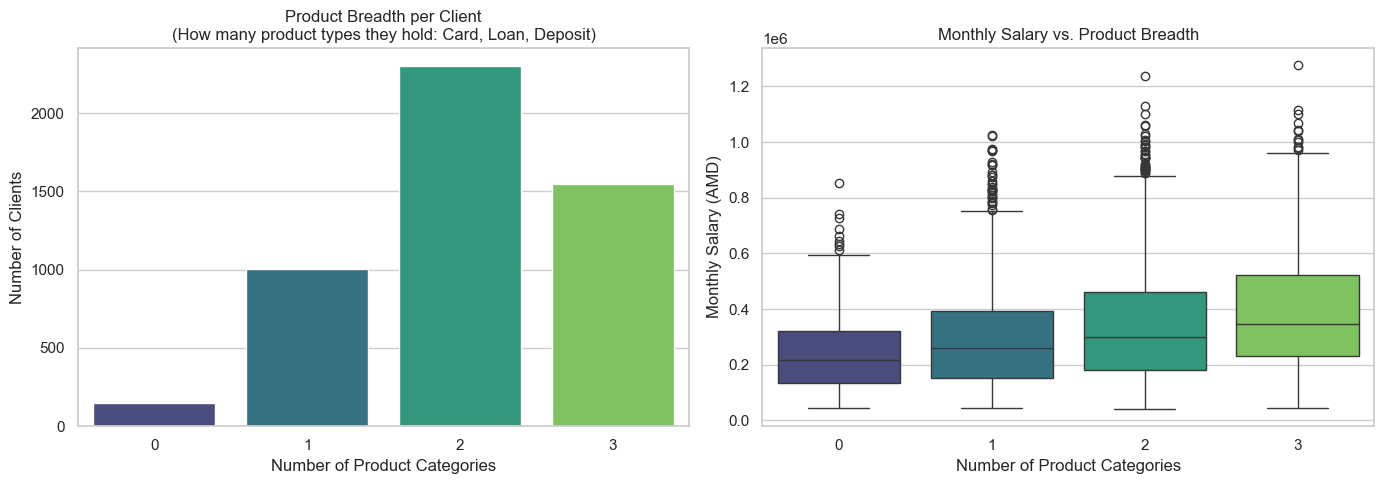

In [57]:
# ==========================================
# Task 4.2 (Extended): EDA - Product Breadth
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Product Breadth Distribution
sns.countplot(data=client_master, x='product_breadth', palette='viridis', ax=axes[0])
axes[0].set_title('Product Breadth per Client\n(How many product types they hold: Card, Loan, Deposit)')
axes[0].set_xlabel('Number of Product Categories')
axes[0].set_ylabel('Number of Clients')

# 2. Product Breadth vs. Monthly Salary
sns.boxplot(data=client_master, x='product_breadth', y='monthly_salary_amd', palette='viridis', ax=axes[1])
axes[1].set_title('Monthly Salary vs. Product Breadth')
axes[1].set_xlabel('Number of Product Categories')
axes[1].set_ylabel('Monthly Salary (AMD)')

plt.tight_layout()
plt.show()

# Business Insight to look for:
# Do higher-earning clients tend to hold more products (breadth = 3)? 
# Is the bank mostly serving single-product clients?

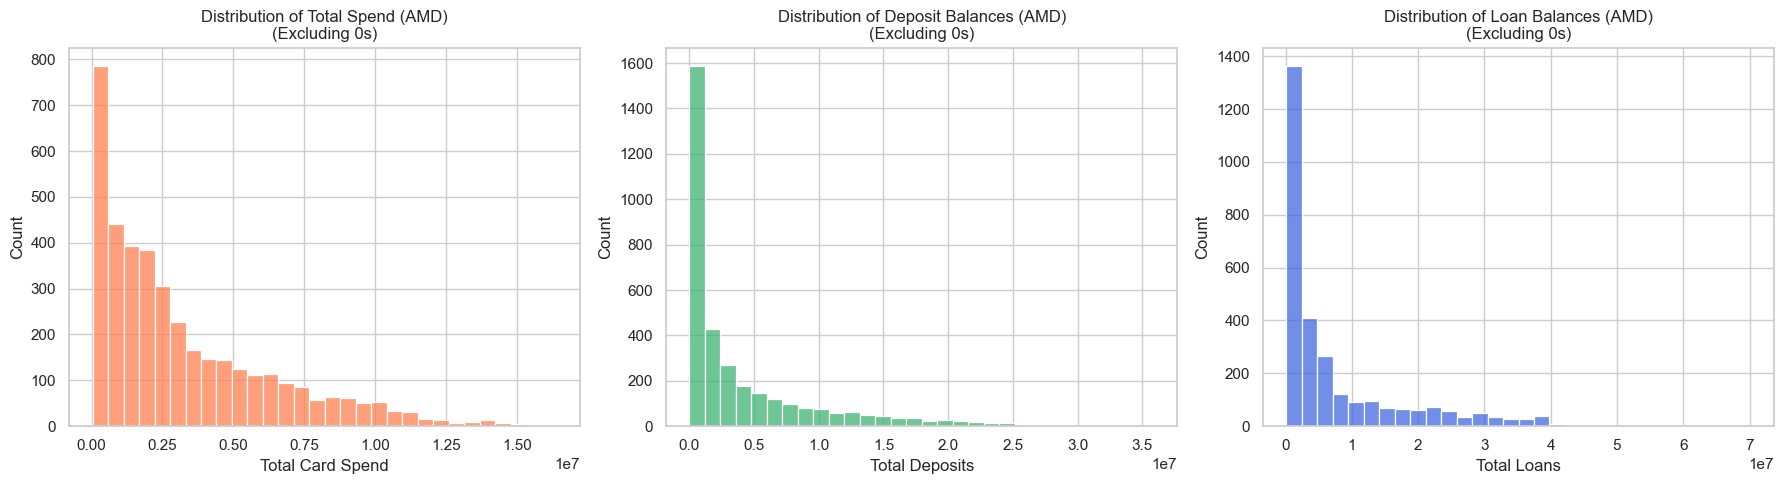

In [58]:
# ==========================================
# Task 4.2 (Extended): EDA - Financial Behaviors
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# We use a slight log scale for financial totals because a few rich clients usually stretch the axis
# 1. Total Transaction Spend
sns.histplot(client_master[client_master['tx_total_amount'] > 0]['tx_total_amount'], 
             bins=30, color='coral', ax=axes[0])
axes[0].set_title('Distribution of Total Spend (AMD)\n(Excluding 0s)')
axes[0].set_xlabel('Total Card Spend')

# 2. Total Deposit Balance
sns.histplot(client_master[client_master['total_deposit_balance'] > 0]['total_deposit_balance'], 
             bins=30, color='mediumseagreen', ax=axes[1])
axes[1].set_title('Distribution of Deposit Balances (AMD)\n(Excluding 0s)')
axes[1].set_xlabel('Total Deposits')

# 3. Total Loan Amount
sns.histplot(client_master[client_master['total_loan_amount'] > 0]['total_loan_amount'], 
             bins=30, color='royalblue', ax=axes[2])
axes[2].set_title('Distribution of Loan Balances (AMD)\n(Excluding 0s)')
axes[2].set_xlabel('Total Loans')

plt.tight_layout()
plt.show()

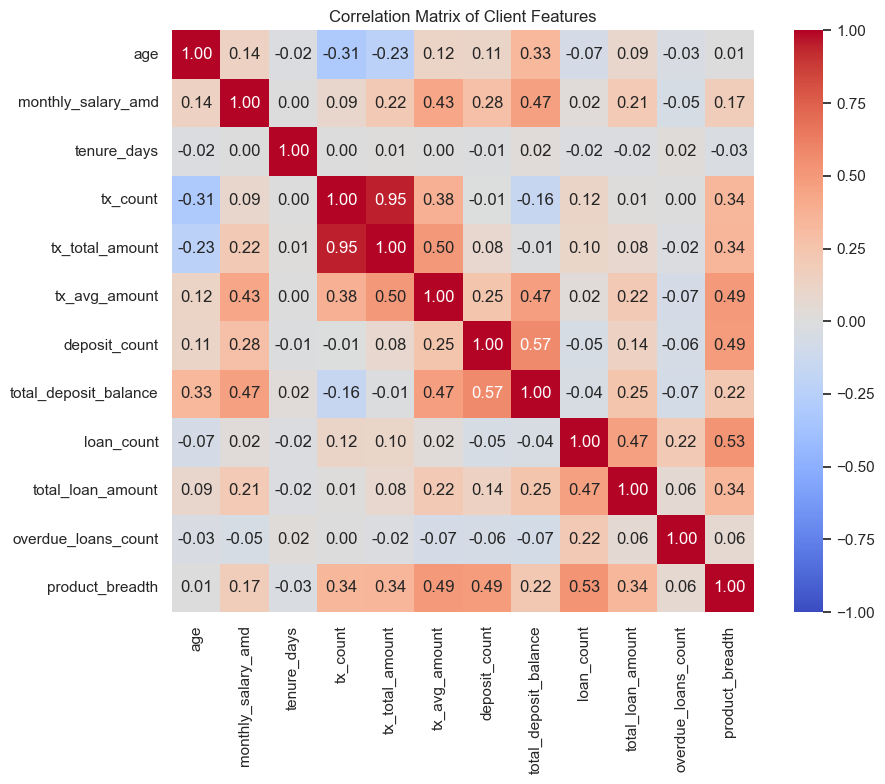

In [59]:
# ==========================================
# Task 4.2 (Extended): Correlation Matrix
# ==========================================
# Select only numerical features relevant for behavioral analysis
numeric_features = [
    'age', 'monthly_salary_amd', 'tenure_days', 
    'tx_count', 'tx_total_amount', 'tx_avg_amount',
    'deposit_count', 'total_deposit_balance', 
    'loan_count', 'total_loan_amount', 'overdue_loans_count',
    'product_breadth'
]

# Calculate correlation
corr_matrix = client_master[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Client Features")
plt.tight_layout()
plt.show()

# Business/Tech Insight to look for:
# If 'tx_count' and 'tx_total_amount' are highly correlated (e.g., > 0.8), 
# we might only want to use one of them in our clustering model to avoid bias!

In [60]:
# ==========================================
# Task 4.4: Preprocessing for Clustering
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Preparing data for clustering...")

# 1. Feature Selection
# We select a mix of demographic, wealth, and behavioral features.
# Note: We omit highly correlated duplicates (e.g., if tx_count and tx_total_amount 
# are highly correlated in your heatmap, we just use tx_total_amount to avoid double-counting).
clustering_features =[
   'age',                   # Dimension: Demographics (mostly independent)
    'monthly_salary_amd',    # Dimension: Wealth/Income
    'tx_total_amount',       # Dimension: Card Spend (We drop tx_count due to 0.95 corr)
    'total_deposit_balance', # Dimension: Savings (We drop deposit_count to keep it simple)
    'total_loan_amount',     # Dimension: Borrowing
    'product_breadth'        # Dimension: Bank Engagement / Cross-sell
]

X = client_master[clustering_features].copy()

# 2. Scaling the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully. Shape of X_scaled:", X_scaled.shape)

Preparing data for clustering...
Data scaled successfully. Shape of X_scaled: (5000, 6)


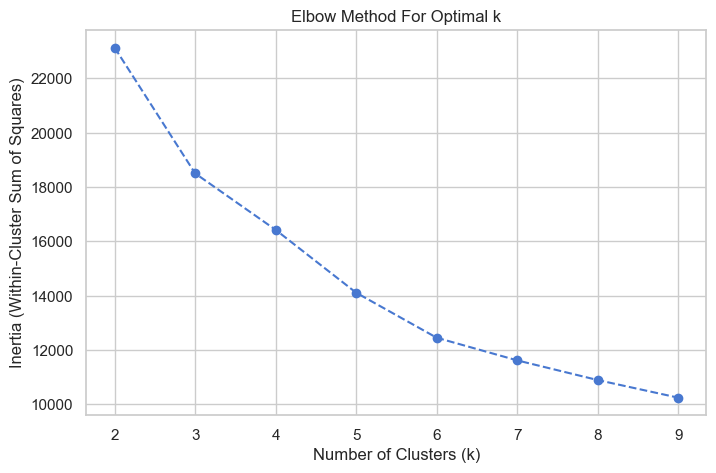

In [61]:
# ==========================================
# Task 4.4: Determining Optimal Clusters (Elbow Method)
# ==========================================
inertia =[]
K_range = range(2, 10)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# INSTRUCTIONS AFTER RUNNING:
# Look at the chart. Where does the sharp drop start to flatten out? 
# Usually, in banking, 3 to 5 clusters is ideal for marketing purposes.

In [62]:
# ==========================================
# Task 4.4 & 4.5: Apply Clustering & Interpret
# ==========================================
OPTIMAL_K = 2  # Adjust this number based on your Elbow Plot if necessary!

# 1. Train the final K-Means model
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
client_master['cluster'] = kmeans.fit_predict(X_scaled)

# 2. Evaluate with Silhouette Score
# (Score ranges from -1 to 1. Higher is better. ~0.2 to 0.5 is standard for real human behavior)
sil_score = silhouette_score(X_scaled, client_master['cluster'])
print(f"Silhouette Score for k={OPTIMAL_K}: {sil_score:.3f}\n")

# 3. Cluster Profiling (The Business View)
# We group by the new cluster label and calculate the average for each feature.
cluster_profile = client_master.groupby('cluster')[clustering_features].mean()

# Add the number of clients in each cluster
cluster_profile['client_count'] = client_master['cluster'].value_counts()
cluster_profile['percentage_of_base'] = (cluster_profile['client_count'] / len(client_master)) * 100

print("--- CLUSTER PROFILES (Average values per segment) ---")
display(cluster_profile.round(1))

Silhouette Score for k=2: 0.301

--- CLUSTER PROFILES (Average values per segment) ---


,age,monthly_salary_amd,tx_total_amount,total_deposit_balance,total_loan_amount,product_breadth,client_count,percentage_of_base
cluster,,,,,,,,
0,36.9,260410.8,1848995.2,671568.1,1942264.2,1.8,3501,70.0
1,43.9,540561.2,4152031.8,7691154.6,10443296.5,2.5,1499,30.0


Applying PCA for visualization...
PCA preserved 56.68% of the original data's variance in 2 dimensions.


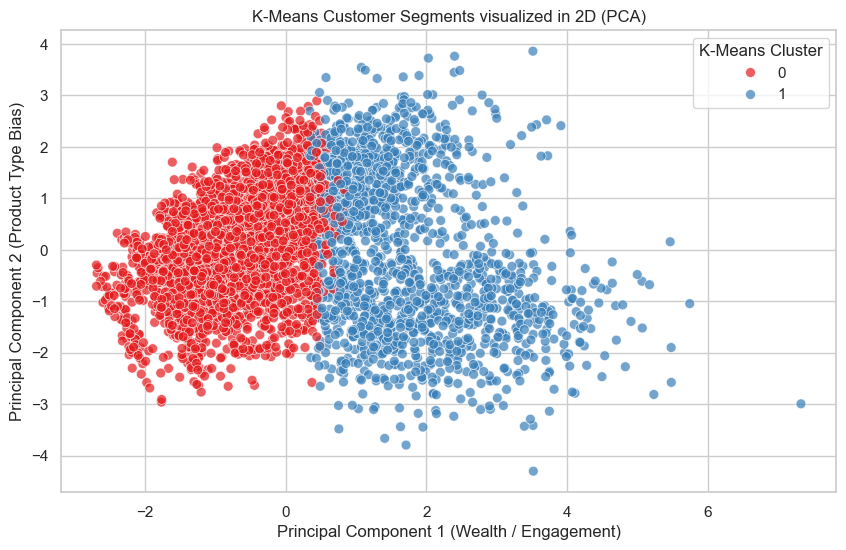

In [63]:
# ==========================================
# Task 4.4: Dimensionality Reduction with PCA
# ==========================================
from sklearn.decomposition import PCA

print("Applying PCA for visualization...")

# Reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to our dataset for plotting
client_master['pca_1'] = X_pca[:, 0]
client_master['pca_2'] = X_pca[:, 1]

# Calculate how much information (variance) is retained by these 2 components
explained_var = pca.explained_variance_ratio_.sum() * 100
print(f"PCA preserved {explained_var:.2f}% of the original data's variance in 2 dimensions.")

# Plot the K-Means clusters using the PCA 2D space
plt.figure(figsize=(10, 6))
sns.scatterplot(data=client_master, x='pca_1', y='pca_2', hue='cluster', 
                palette='Set1', alpha=0.7, s=50)
plt.title('K-Means Customer Segments visualized in 2D (PCA)')
plt.xlabel('Principal Component 1 (Wealth / Engagement)')
plt.ylabel('Principal Component 2 (Product Type Bias)')
plt.legend(title='K-Means Cluster')
plt.show()

# Insight: 
# If the clusters look distinct in this 2D space, the K-Means model did a good job!

--- Evaluating Silhouette Scores for PCA-transformed data ---
k=2 | Silhouette Score: 0.4343
k=3 | Silhouette Score: 0.4366
k=4 | Silhouette Score: 0.3793
k=5 | Silhouette Score: 0.3782
k=6 | Silhouette Score: 0.3327
k=7 | Silhouette Score: 0.3409
k=8 | Silhouette Score: 0.3272
k=9 | Silhouette Score: 0.3370


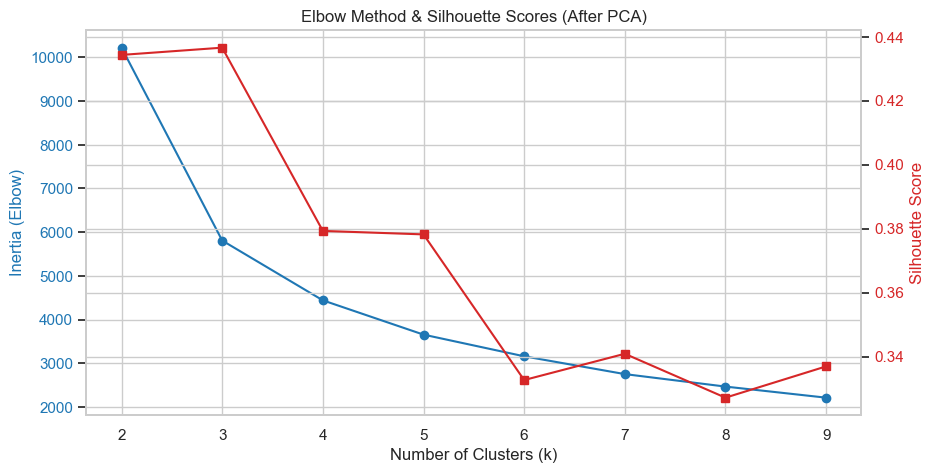


Applying final K-Means with k=3


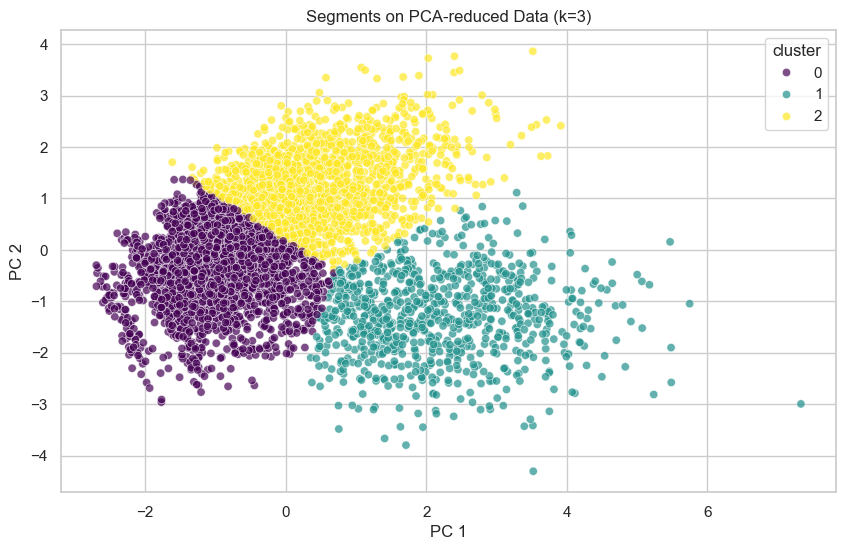

In [64]:
inertia = []
sil_scores = []
print("--- Evaluating Silhouette Scores for PCA-transformed data ---")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_pca)
    
    # Calculate scores
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)
    inertia.append(kmeans_temp.inertia_)
    
    print(f"k={k} | Silhouette Score: {score:.4f}")

# 4. Visualizing results to find the best k
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color='tab:blue')
ax1.plot(K_range, inertia, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, sil_scores, marker='s', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method & Silhouette Scores (After PCA)')
plt.show()

# 5. Final K-Means on PCA Data
# Select the k that gives the highest Silhouette Score or the best "elbow"
OPTIMAL_K = K_range[np.argmax(sil_scores)] 
print(f"\nApplying final K-Means with k={OPTIMAL_K}")

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
client_master['cluster'] = kmeans_final.fit_predict(X_pca)

# 6. Visualization in 2D
# (Even if PCA used more components, we use the first two for the plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=client_master['cluster'], 
    palette='viridis', alpha=0.7
)
plt.title(f'Segments on PCA-reduced Data (k={OPTIMAL_K})')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

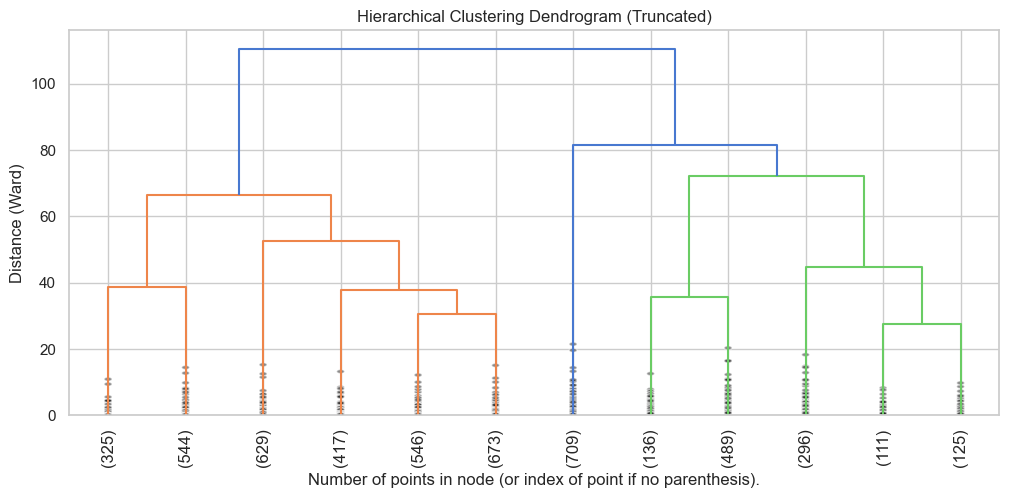

Hierarchical Clustering completed.


In [65]:
# ==========================================
# Task 4.4: Hierarchical Clustering
# ==========================================
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Generate the Linkage Matrix (Using Ward's method to minimize variance)
# We calculate this on the scaled data
Z = linkage(X_scaled, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(12, 5))
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Number of points in node (or index of point if no parenthesis).')
plt.ylabel('Distance (Ward)')

# We truncate the dendrogram because plotting 5000 individual leaves is unreadable
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,                   # show the top 12 branches
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
)
plt.show()

# 3. Apply Agglomerative Clustering
# We use the same OPTIMAL_K we found from the Elbow method (e.g., 4)
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, metric='euclidean', linkage='ward')
client_master['cluster_hc'] = hc.fit_predict(X_scaled)

print("Hierarchical Clustering completed.")

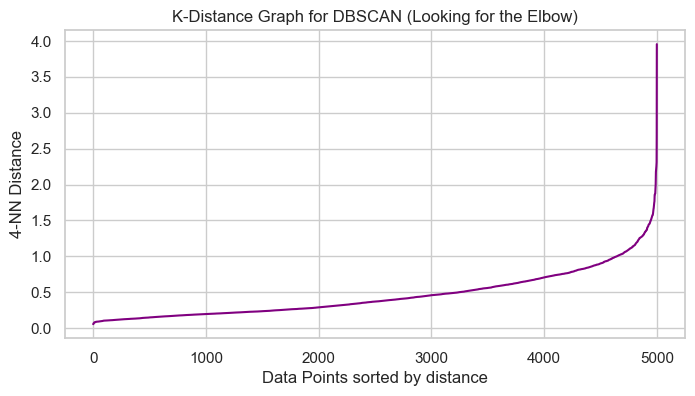

Mathematically suggested epsilon: 1.0948
DBSCAN Cluster Counts:
Note: Cluster -1 represents NOISE / OUTLIERS (Clients who don't fit into any standard group)
cluster_dbscan
-1     281
 0    2214
 1     970
 2    1392
 3     143
Name: count, dtype: int64


In [37]:
# ==========================================
# Task 4.4: DBSCAN (Density-Based Spatial Clustering)
# ==========================================
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Finding optimal 'eps' using the K-distance Graph
# DBSCAN needs two parameters: 'eps' (radius) and 'min_samples'.
# We plot the distance to the k-th nearest neighbor to find the 'elbow' for eps.
k_neighbors = 4
nearest_neighbors = NearestNeighbors(n_neighbors=k_neighbors)
neighbors_fit = nearest_neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, k_neighbors-1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph for DBSCAN (Looking for the Elbow)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{k_neighbors}-NN Distance')
plt.show()

# 2. Apply DBSCAN
# Note: You might need to adjust 'eps' based on where the elbow is in the chart above!
# eps = 1.5 is a common starting point for scaled data.
optimal_eps = np.percentile(distances, 95) 
print(f"Mathematically suggested epsilon: {optimal_eps:.4f}")

dbscan = DBSCAN(eps=optimal_eps, min_samples=10)
client_master['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Check the results
dbscan_counts = client_master['cluster_dbscan'].value_counts().sort_index()
print("DBSCAN Cluster Counts:")
print("Note: Cluster -1 represents NOISE / OUTLIERS (Clients who don't fit into any standard group)")
print(dbscan_counts)

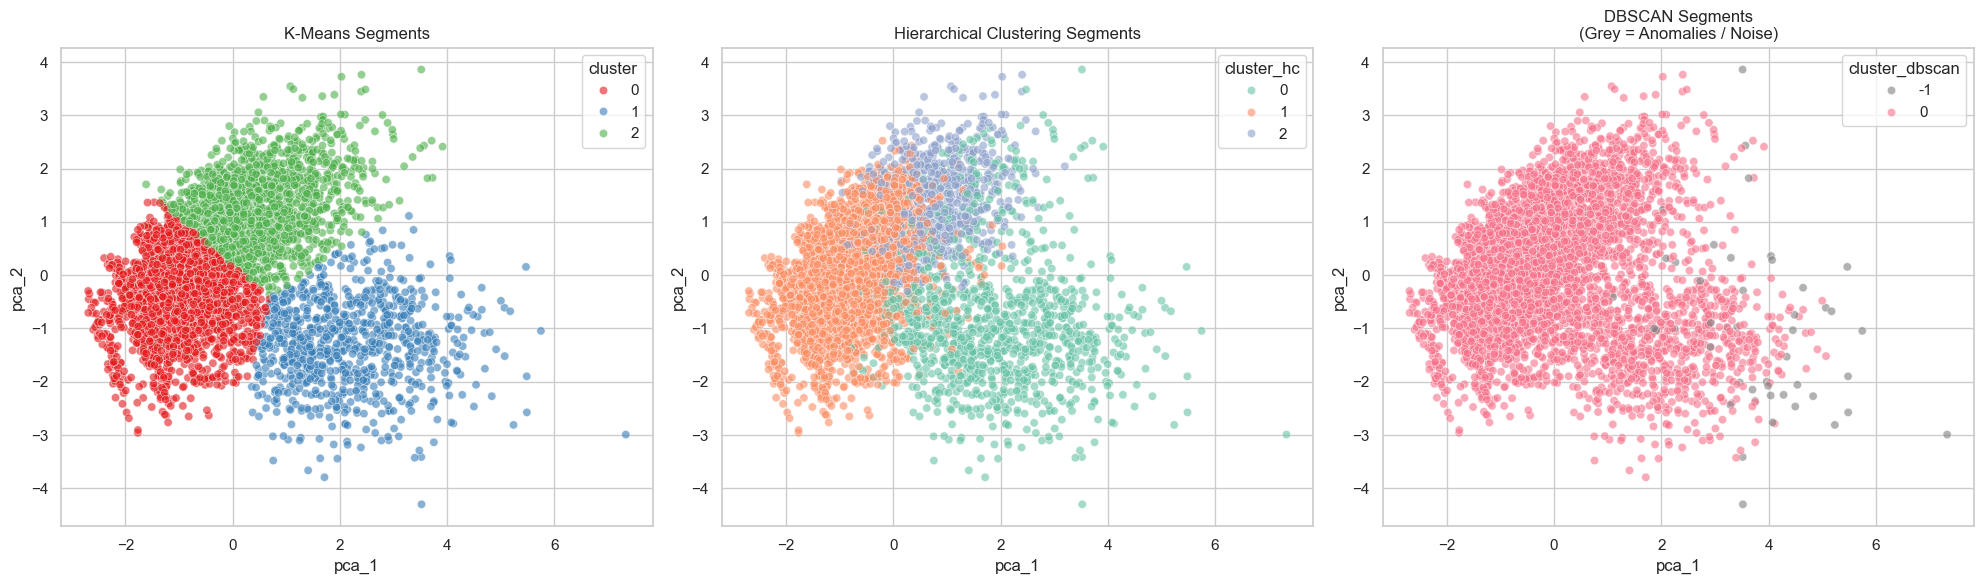

In [67]:
# ==========================================
# Task 4.4: Comparing Algorithms (Visual Check)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: K-Means
sns.scatterplot(data=client_master, x='pca_1', y='pca_2', hue='cluster', 
                palette='Set1', ax=axes[0], alpha=0.6)
axes[0].set_title('K-Means Segments')

# Plot 2: Hierarchical Clustering
sns.scatterplot(data=client_master, x='pca_1', y='pca_2', hue='cluster_hc', 
                palette='Set2', ax=axes[1], alpha=0.6)
axes[1].set_title('Hierarchical Clustering Segments')

# Plot 3: DBSCAN
# We make the noise points (-1) grey, and real clusters colored
unique_labels = client_master['cluster_dbscan'].unique()
colors = sns.color_palette("husl", len(unique_labels))

dbscan_palette = {label: ('grey' if label == -1 else colors[i]) 
                  for i, label in enumerate(unique_labels)}

sns.scatterplot(data=client_master, x='pca_1', y='pca_2', hue='cluster_dbscan', 
                palette=dbscan_palette, ax=axes[2], alpha=0.6)
axes[2].set_title('DBSCAN Segments\n(Grey = Anomalies / Noise)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FINAL EVALUATION COMMENT FOR YOUR NOTEBOOK:
# ---------------------------------------------------------
# Which model is best?
# K-Means and Hierarchical Clustering usually yield very similar, practical business segments.
# DBSCAN is harder to use for standard marketing segmentation (because it classifies many people as "noise"), 
# but it is incredibly valuable for finding outliers, ultra-high-net-worth individuals, or potential fraud cases!